In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/onyekamuoka/object-level-all-wsi/object_level_take_2_dcis/bracs-wsi-group-mt-type-dcis_slides_45_59_features.csv
/kaggle/input/datasets/onyekamuoka/object-level-all-wsi/object_level_take_2_dcis/bracs-wsi-group-mt-type-dcis_slides_60_74_features.csv
/kaggle/input/datasets/onyekamuoka/object-level-all-wsi/object_level_take_2_dcis/bracs-wsi-group-mt-type-dcis_slides_15_29_features.csv
/kaggle/input/datasets/onyekamuoka/object-level-all-wsi/object_level_take_2_dcis/bracs-wsi-group-mt-type-dcis_slides_30_44_features.csv
/kaggle/input/datasets/onyekamuoka/object-level-all-wsi/object_level_take_2_dcis/bracs-wsi-group-mt-type-dcis_slides_0_14_features.csv
/kaggle/input/datasets/onyekamuoka/object-level-all-wsi/object level take two fea/bracs-wsi-group-at-type-fea_slides_0_14_features.csv
/kaggle/input/datasets/onyekamuoka/object-level-all-wsi/object level take two fea/bracs-wsi-group-at-type-fea_slides_15_29_features.csv
/kaggle/input/datasets/onyekamuoka/object-level-al

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import lightgbm as lgb
from sklearn.metrics import accuracy_score
import os
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


In [3]:
type_pb_02 = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-bt-type-pb-02_slide_features.csv')
type_dcis = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-mt-type-dcis_slide_features.csv')
type_ic_02 = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-mt-type-ic-02_slide_features.csv')
type_adh = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-at-type-adh_slide_features.csv')
type_ic_01 = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-mt-type-ic-01_slide_features.csv')
type_pb_01 = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-bt-type-pb-01_slide_features.csv')
type_udh = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-bt-type-udh_slide_features.csv')
type_fea = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-at-type-fea_slide_features.csv')
type_n = pd.read_csv('/kaggle/input/all-wsi/bracs-wsi-group-bt-type-n_slide_features.csv')

In [4]:
type_pb_02['source'] = 'type_pb_02'
type_dcis['source']= 'type_dcis'
type_ic_02['source'] = 'type_ic_02'
type_adh['source'] = 'type_adh'
type_ic_01['source'] = 'type_ic_01'
type_pb_01['source'] = 'type_pb_01'
type_udh['source'] = 'type_udh'
type_fea['source'] = 'type_fea'
type_n['source']= 'type_n'

In [5]:
type_pb_02

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-bt-type-pb-02_BRACS_1989.svs,1068,158.583887,5.721452,143.352448,178.958054,158.017235,155.119778,161.457333,66.881571,...,7.434232e+06,4.035028e+06,1.439737e+06,2.866467e+07,6.649404e+06,4.175079e+06,9.817391e+06,0.983223,0.089668,type_pb_02
1,bracs-wsi-group-bt-type-pb-02_BRACS_1866.svs,2638,151.935569,6.024752,134.666107,191.869247,151.364761,147.606293,155.692341,67.548162,...,1.021875e+07,4.814098e+06,4.937811e+05,3.163030e+07,9.036082e+06,6.778973e+06,1.262198e+07,0.961559,0.128646,type_pb_02
2,bracs-wsi-group-bt-type-pb-02_BRACS_1796.svs,3366,152.657995,10.070952,131.752686,243.046677,153.252869,143.343468,161.579025,70.115924,...,3.222389e+06,2.182857e+06,1.577918e+05,1.516708e+07,2.713560e+06,1.571117e+06,4.396761e+06,0.976035,0.102853,type_pb_02
3,bracs-wsi-group-bt-type-pb-02_BRACS_1988.svs,3854,158.159678,5.940128,138.989120,180.517075,157.411613,154.390186,160.816948,68.430810,...,1.101291e+07,5.873268e+06,4.143238e+05,3.264744e+07,1.111402e+07,6.004910e+06,1.540357e+07,0.988710,0.072414,type_pb_02
4,bracs-wsi-group-bt-type-pb-02_BRACS_1832.svs,2339,151.591300,9.715918,132.596237,226.244598,151.851349,142.874222,159.996063,70.380794,...,4.410442e+06,2.570877e+06,1.142986e+05,1.797780e+07,3.824103e+06,2.402468e+06,5.880593e+06,0.924135,0.178421,type_pb_02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,bracs-wsi-group-bt-type-pb-02_BRACS_1852.svs,3772,157.700708,8.531292,89.463745,172.114960,159.576256,153.467449,163.949749,70.456779,...,9.678703e+06,6.353415e+06,7.007350e+04,3.885240e+07,8.687434e+06,4.348631e+06,1.382305e+07,0.977952,0.100471,type_pb_02
69,bracs-wsi-group-bt-type-pb-02_BRACS_3312.svs,2045,157.461371,9.201360,136.572418,198.426682,156.932205,149.688065,164.585526,66.900192,...,8.577375e+06,4.511943e+06,1.032390e+06,3.660122e+07,7.454329e+06,5.268771e+06,1.094399e+07,0.964992,0.121149,type_pb_02
70,bracs-wsi-group-bt-type-pb-02_BRACS_1869.svs,1676,157.364322,6.379683,137.197723,188.641800,157.701935,153.005573,162.340622,68.057461,...,6.655142e+06,3.635481e+06,4.891243e+05,1.931120e+07,5.733505e+06,3.922449e+06,8.762319e+06,0.979774,0.095232,type_pb_02
71,bracs-wsi-group-bt-type-pb-02_BRACS_1924.svs,3060,147.984480,7.690434,133.832947,175.053894,145.886803,141.843796,153.511879,71.263980,...,3.980475e+06,2.800996e+06,2.762481e+05,2.255664e+07,3.245576e+06,1.901623e+06,5.417795e+06,0.904715,0.193900,type_pb_02


In [6]:
type_pb_02.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 234.5+ KB


In [7]:
type_dcis

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-mt-type-dcis_BRACS_1514.svs,421,138.818620,11.691056,129.613800,229.298386,135.627472,132.971100,139.355270,73.384624,...,3.861134e+06,2.356144e+06,4.552923e+05,1.640355e+07,3.290343e+06,2.163087e+06,5.146268e+06,0.815987,0.234470,type_dcis
1,bracs-wsi-group-mt-type-dcis_BRACS_1490.svs,507,135.127939,5.556805,129.675110,173.383820,133.825974,132.545082,135.314034,70.860914,...,8.802686e+06,3.603099e+06,9.927203e+05,2.389358e+07,8.345471e+06,5.992228e+06,1.081535e+07,0.909592,0.180204,type_dcis
2,bracs-wsi-group-mt-type-dcis_BRACS_1003697.svs,1002,146.004375,5.146519,136.437363,172.402237,145.012474,142.091614,149.506470,69.637544,...,6.144003e+06,3.435408e+06,1.024042e+06,1.900734e+07,5.321884e+06,3.413667e+06,8.133070e+06,0.896493,0.195240,type_dcis
3,bracs-wsi-group-mt-type-dcis_BRACS_1897.svs,1124,134.372110,2.372003,129.445358,171.147263,134.214264,133.180645,135.316212,71.959933,...,5.714764e+06,2.957589e+06,5.528207e+05,2.214069e+07,5.018694e+06,3.636267e+06,7.051395e+06,0.958185,0.137661,type_dcis
4,bracs-wsi-group-mt-type-dcis_BRACS_1653.svs,884,143.840053,6.799558,133.021118,177.249039,142.400497,138.855400,147.167431,69.666940,...,3.860891e+06,2.266633e+06,3.667654e+05,1.507631e+07,3.224542e+06,2.297241e+06,4.773715e+06,0.933886,0.163374,type_dcis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,bracs-wsi-group-mt-type-dcis_BRACS_1283.svs,632,147.773619,13.843931,19.617615,200.571060,146.868271,143.140385,152.143635,69.064275,...,7.334976e+06,4.350725e+06,1.037331e+05,2.442517e+07,6.326174e+06,3.744922e+06,9.894242e+06,0.885373,0.209224,type_dcis
57,bracs-wsi-group-mt-type-dcis_BRACS_1496.svs,915,138.025303,5.677943,130.328720,206.976318,137.161011,134.986526,139.801590,70.840197,...,6.529410e+06,4.003304e+06,1.172303e+06,2.618692e+07,5.383972e+06,3.578840e+06,8.521178e+06,0.922137,0.168722,type_dcis
58,bracs-wsi-group-mt-type-dcis_BRACS_1489.svs,584,137.744485,4.625898,130.745865,174.621475,136.933105,134.728897,139.559246,71.114081,...,5.729526e+06,3.376521e+06,1.504520e+06,2.215929e+07,4.746640e+06,3.345671e+06,7.026744e+06,0.913056,0.187262,type_dcis
59,bracs-wsi-group-mt-type-dcis_BRACS_1927.svs,4281,151.864283,5.720084,134.917694,189.151428,151.674881,147.872452,155.362946,68.744257,...,9.401403e+06,6.697196e+06,9.351827e+04,3.781091e+07,7.459492e+06,3.983148e+06,1.363925e+07,0.978300,0.095429,type_dcis


In [8]:
type_dcis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 196.0+ KB


In [9]:
type_ic_02

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-mt-type-ic-02_BRACS_747.svs,1537,151.621810,7.430533,122.157303,230.622757,151.748184,147.502167,155.169312,69.600778,...,6.290488e+06,3.597527e+06,6.241571e+04,2.104776e+07,5.236698e+06,3.631289e+06,8.229584e+06,0.934779,0.165916,type_ic_02
1,bracs-wsi-group-mt-type-ic-02_BRACS_749.svs,2419,152.205683,7.128976,138.169220,226.988434,152.389908,147.830261,155.677277,69.693634,...,1.175277e+07,5.074139e+06,2.379596e+06,3.263620e+07,1.113652e+07,7.919159e+06,1.473200e+07,0.951101,0.146318,type_ic_02
2,bracs-wsi-group-mt-type-ic-02_BRACS_3319.svs,2559,160.965669,11.092027,16.490845,184.139145,162.811874,157.233452,166.922462,68.268632,...,6.259136e+06,2.824567e+06,2.583512e+04,2.199426e+07,5.826862e+06,4.388656e+06,7.569130e+06,0.989015,0.073587,type_ic_02
3,bracs-wsi-group-mt-type-ic-02_BRACS_1817.svs,2673,149.386127,5.705339,135.267975,195.992752,148.846695,145.286560,153.007645,67.794575,...,6.365537e+06,3.680748e+06,7.703826e+05,2.588853e+07,5.379119e+06,3.880138e+06,7.577236e+06,0.961222,0.130060,type_ic_02
4,bracs-wsi-group-mt-type-ic-02_BRACS_1810.svs,2072,151.887301,6.814561,133.948700,175.689743,152.075569,147.389866,156.869690,68.457535,...,7.547931e+06,4.636534e+06,1.121738e+06,2.526720e+07,6.176710e+06,4.072261e+06,9.763089e+06,0.949039,0.148180,type_ic_02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,bracs-wsi-group-mt-type-ic-02_BRACS_773.svs,4720,154.061143,7.649579,134.088867,232.162720,155.867714,150.058052,158.871414,71.341777,...,9.378726e+06,4.621874e+06,2.878201e+05,3.181316e+07,8.461947e+06,5.945869e+06,1.189359e+07,0.984720,0.085216,type_ic_02
62,bracs-wsi-group-mt-type-ic-02_BRACS_1830.svs,3263,145.547320,5.378109,132.951035,179.695679,145.069244,141.377129,148.867378,68.552380,...,6.259734e+06,3.013719e+06,8.902918e+04,2.606972e+07,5.373518e+06,4.134960e+06,7.756111e+06,0.938244,0.161696,type_ic_02
63,bracs-wsi-group-mt-type-ic-02_BRACS_757.svs,1195,153.127089,6.831937,136.505768,209.038116,153.155289,148.524948,156.945595,71.034138,...,5.230186e+06,2.603794e+06,4.595478e+05,1.555020e+07,4.423204e+06,3.374232e+06,6.661853e+06,0.934472,0.167726,type_ic_02
64,bracs-wsi-group-mt-type-ic-02_BRACS_734.svs,3379,153.552262,6.057104,110.598602,203.434082,154.683624,150.527069,157.524734,70.038879,...,4.058722e+06,2.492134e+06,1.985746e+05,1.961310e+07,3.287610e+06,2.321181e+06,4.999511e+06,0.978499,0.097625,type_ic_02


In [10]:
type_ic_02.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 212.1+ KB


In [11]:
type_adh

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-at-type-adh_BRACS_1003728.svs,47,136.057360,6.288892,130.454834,162.253174,134.049652,132.981544,135.349129,71.833296,...,6.571947e+06,3.712379e+06,1.812328e+06,1.502527e+07,5.342258e+06,3.183237e+06,8.541345e+06,0.841608,0.238244,type_adh
1,bracs-wsi-group-at-type-adh_BRACS_1982.svs,805,155.407375,8.637245,137.380890,239.203598,154.395340,148.955872,161.274734,68.349680,...,7.752783e+06,3.840567e+06,1.472403e+06,2.580978e+07,6.855253e+06,4.859782e+06,9.778430e+06,0.913182,0.182184,type_adh
2,bracs-wsi-group-at-type-adh_BRACS_1882.svs,1251,154.127862,8.687170,136.310699,214.828842,154.295197,146.796387,160.945999,68.662831,...,5.281192e+06,3.501625e+06,5.935225e+05,2.321270e+07,4.116749e+06,2.690680e+06,6.837967e+06,0.954991,0.136800,type_adh
3,bracs-wsi-group-at-type-adh_BRACS_1808.svs,3040,153.298229,6.880751,130.567413,168.713699,153.314987,148.516087,158.471352,70.224852,...,3.191504e+06,2.932481e+06,9.072182e+03,1.857384e+07,2.314505e+06,1.077906e+06,4.593760e+06,0.982089,0.090260,type_adh
4,bracs-wsi-group-at-type-adh_BRACS_1933.svs,3166,148.976878,6.577512,65.908661,199.778992,148.677223,144.751831,152.716770,67.371273,...,8.017276e+06,3.548197e+06,2.611012e+05,2.538484e+07,7.301321e+06,5.452754e+06,9.937924e+06,0.975082,0.108298,type_adh
5,bracs-wsi-group-at-type-adh_BRACS_1861.svs,3729,150.015360,6.831569,97.361328,218.563156,149.520554,145.660629,154.125153,67.841061,...,7.728716e+06,4.376842e+06,2.016907e+05,3.222060e+07,6.750039e+06,4.653403e+06,9.690214e+06,0.982807,0.088736,type_adh
6,bracs-wsi-group-at-type-adh_BRACS_1877.svs,2180,161.036317,7.546550,137.895172,202.944641,161.732216,155.964172,166.740471,68.279979,...,6.547792e+06,4.304374e+06,1.071255e+06,2.674415e+07,5.146923e+06,3.358138e+06,8.667837e+06,0.982653,0.088885,type_adh
7,bracs-wsi-group-at-type-adh_BRACS_1486.svs,2239,141.004388,7.341265,130.333893,240.362686,139.598572,136.771088,143.415703,70.447822,...,4.423376e+06,3.027654e+06,1.250788e+05,2.294981e+07,3.685255e+06,2.356459e+06,5.605463e+06,0.963625,0.126939,type_adh
8,bracs-wsi-group-at-type-adh_BRACS_1379.svs,542,136.925227,4.631104,130.013382,168.763107,135.596878,134.558273,137.705620,70.421766,...,8.340027e+06,4.638650e+06,6.034085e+04,3.124544e+07,7.240065e+06,5.195514e+06,1.071169e+07,0.873710,0.201471,type_adh
9,bracs-wsi-group-at-type-adh_BRACS_1895.svs,788,136.545836,4.384830,128.957489,171.981979,135.781425,133.976517,138.004478,72.641962,...,6.354386e+06,3.285303e+06,2.023782e+05,2.436225e+07,5.765489e+06,4.014506e+06,7.956794e+06,0.905547,0.186630,type_adh


In [12]:
type_adh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 154.3+ KB


In [13]:
type_ic_01

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-mt-type-ic-01_BRACS_1003667.svs,840,141.386813,4.571377,127.152618,171.063278,140.834419,138.506634,143.847290,70.720356,...,1.043881e+07,6.557146e+06,24006.647680,4.523635e+07,1.004697e+07,5.148995e+06,1.444309e+07,0.968651,0.120216,type_ic_01
1,bracs-wsi-group-mt-type-ic-01_BRACS_1279.svs,2001,154.176323,7.694775,75.285156,228.434753,153.728745,150.765289,157.432510,67.054354,...,7.719156e+06,3.893648e+06,334122.635370,3.047282e+07,6.498678e+06,5.115476e+06,9.254480e+06,0.981774,0.087183,type_ic_01
2,bracs-wsi-group-mt-type-ic-01_BRACS_1360.svs,2277,154.395679,6.113969,137.587433,192.707367,155.954239,150.747757,158.256943,69.956045,...,5.038272e+06,3.120514e+06,534873.327679,2.019980e+07,4.080093e+06,2.861062e+06,6.193362e+06,0.964445,0.125243,type_ic_01
3,bracs-wsi-group-mt-type-ic-01_BRACS_1265.svs,2490,153.547905,6.651000,137.450027,214.158844,154.909836,149.844566,157.964958,71.116885,...,6.202131e+06,2.927596e+06,910599.977754,2.147658e+07,5.503837e+06,4.406888e+06,7.131402e+06,0.968339,0.119444,type_ic_01
4,bracs-wsi-group-mt-type-ic-01_BRACS_1358.svs,1679,151.043283,6.805251,87.985992,206.190598,150.874344,146.846107,155.228592,67.203181,...,4.576550e+06,3.357421e+06,17687.231927,2.175003e+07,3.473558e+06,2.568573e+06,5.624207e+06,0.926560,0.174206,type_ic_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,bracs-wsi-group-mt-type-ic-01_BRACS_1477.svs,1597,137.738190,5.010362,128.714294,207.421249,136.862091,134.858444,139.499969,71.474274,...,3.743060e+06,2.047529e+06,449025.521373,1.706401e+07,3.390668e+06,2.325410e+06,4.574043e+06,0.971126,0.114037,type_ic_01
62,bracs-wsi-group-mt-type-ic-01_BRACS_1639.svs,4945,157.999840,8.958420,128.896484,186.457458,160.506989,151.628082,164.066589,71.299708,...,4.776672e+06,2.847598e+06,19801.442771,3.335323e+07,4.213133e+06,3.000902e+06,5.700646e+06,0.987450,0.075118,type_ic_01
63,bracs-wsi-group-mt-type-ic-01_BRACS_1233.svs,3635,152.343483,8.870763,17.821411,209.134567,153.772293,146.533470,158.933952,68.634303,...,1.044596e+07,4.453032e+06,199173.750088,3.262872e+07,9.968872e+06,7.578845e+06,1.247635e+07,0.988018,0.075631,type_ic_01
64,bracs-wsi-group-mt-type-ic-01_BRACS_1003684.svs,827,144.585985,8.705912,41.317505,213.217575,143.636917,139.560722,149.424583,70.288974,...,7.657924e+06,4.824255e+06,103600.867961,2.439870e+07,6.341806e+06,3.960193e+06,1.054248e+07,0.954051,0.137697,type_ic_01


In [14]:
type_ic_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 212.1+ KB


In [15]:
type_pb_01

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-bt-type-pb-01_BRACS_1493.svs,298,133.491519,4.034522,129.480423,182.784698,132.788879,131.593925,134.028877,71.559821,...,3.935517e+06,2.028638e+06,115180.311213,1.290919e+07,3.587156e+06,2.485237e+06,5.079753e+06,0.811464,0.224199,type_pb_01
1,bracs-wsi-group-bt-type-pb-01_BRACS_1003659.svs,1873,135.082729,15.481568,59.595612,173.416656,137.822983,136.074982,139.619263,70.875829,...,1.083772e+07,5.748133e+06,787171.911544,3.406485e+07,1.002558e+07,6.374881e+06,1.453373e+07,0.976083,0.100846,type_pb_01
2,bracs-wsi-group-bt-type-pb-01_BRACS_1003730.svs,2452,150.579250,12.807896,39.199738,214.325531,149.967361,143.578392,157.581001,67.978185,...,7.831907e+06,6.396992e+06,442035.297479,4.263101e+07,5.857981e+06,3.507180e+06,1.019030e+07,0.964918,0.121825,type_pb_01
3,bracs-wsi-group-bt-type-pb-01_BRACS_1423.svs,299,137.714635,6.014205,129.446457,185.722305,136.021545,134.150482,139.523651,70.642741,...,3.801098e+06,2.558723e+06,150954.442203,1.833735e+07,3.176254e+06,2.117745e+06,4.583911e+06,0.894888,0.186588,type_pb_01
4,bracs-wsi-group-bt-type-pb-01_BRACS_1003669.svs,494,140.072982,5.119151,131.651047,161.324982,138.951408,136.179127,143.382435,69.349307,...,8.023507e+06,4.557619e+06,617594.111379,2.375336e+07,7.245257e+06,4.537754e+06,1.028823e+07,0.937697,0.162130,type_pb_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,bracs-wsi-group-bt-type-pb-01_BRACS_1324.svs,4517,140.638076,4.524168,131.322784,222.007019,140.433228,137.841431,142.693329,71.804793,...,1.369187e+07,6.852880e+06,449382.953327,4.934641e+07,1.331746e+07,8.481506e+06,1.815097e+07,0.991542,0.060054,type_pb_01
70,bracs-wsi-group-bt-type-pb-01_BRACS_1320.svs,4684,151.569729,7.334175,132.219040,191.405304,152.587463,146.403496,157.050140,72.535443,...,4.978019e+06,3.783803e+06,167077.607269,2.860734e+07,4.009418e+06,2.350122e+06,6.443649e+06,0.980548,0.097534,type_pb_01
71,bracs-wsi-group-bt-type-pb-01_BRACS_1322.svs,4859,149.434593,7.644568,82.859818,186.439560,149.349762,144.098511,154.429604,71.970626,...,1.120031e+07,6.200114e+06,179220.848037,3.566309e+07,1.127042e+07,6.534204e+06,1.519739e+07,0.991493,0.063115,type_pb_01
72,bracs-wsi-group-bt-type-pb-01_BRACS_1511.svs,68,140.134375,5.199500,128.842087,156.731415,139.970047,136.103065,142.676506,69.006575,...,3.033180e+06,1.898854e+06,628630.977872,1.362425e+07,2.367624e+06,1.791063e+06,3.831883e+06,0.888655,0.188581,type_pb_01


In [16]:
type_pb_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 237.7+ KB


In [17]:
type_udh

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-bt-type-udh_BRACS_3317.svs,349,156.098819,10.390488,135.575714,191.405426,156.498550,147.705978,163.611084,67.344076,...,6.400370e+06,3.642941e+06,9.879419e+05,1.707971e+07,5.866506e+06,3.124854e+06,9.145923e+06,0.877924,0.211874,type_udh
1,bracs-wsi-group-bt-type-udh_BRACS_1957.svs,428,132.651139,3.978738,128.041321,160.161057,131.946053,130.536343,133.352200,71.743157,...,7.352169e+06,4.503813e+06,7.545019e+05,2.485050e+07,6.267068e+06,4.077516e+06,9.452209e+06,0.844496,0.225879,type_udh
2,bracs-wsi-group-bt-type-udh_BRACS_1824.svs,721,146.806973,6.799967,132.864990,190.889435,145.731400,141.568161,151.996765,68.864174,...,1.048192e+07,5.027618e+06,2.025973e+06,3.221048e+07,9.626785e+06,6.396048e+06,1.355775e+07,0.883071,0.211148,type_udh
3,bracs-wsi-group-bt-type-udh_BRACS_1621.svs,516,135.151175,4.005974,129.220505,152.743881,133.773438,132.345909,136.905334,70.740069,...,1.088295e+07,4.768990e+06,6.538380e+05,2.592206e+07,1.051749e+07,7.107981e+06,1.388075e+07,0.954350,0.138215,type_udh
4,bracs-wsi-group-bt-type-udh_BRACS_1596.svs,1035,154.378028,10.680467,123.814667,237.401520,154.675262,146.746727,162.562454,69.983977,...,7.391157e+06,4.219752e+06,3.276541e+05,2.396874e+07,6.664090e+06,4.105243e+06,1.012177e+07,0.957166,0.136878,type_udh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,bracs-wsi-group-bt-type-udh_BRACS_3278.svs,1752,138.412843,4.579328,131.714554,176.335144,137.103935,135.511635,139.922459,70.129074,...,1.166314e+07,6.933598e+06,1.634408e+05,3.518021e+07,9.911841e+06,6.692112e+06,1.530768e+07,0.920476,0.177069,type_udh
70,bracs-wsi-group-bt-type-udh_BRACS_1914.svs,5051,151.833057,7.280010,133.650818,175.905045,153.497864,146.394630,157.345047,70.727534,...,3.858473e+06,2.493032e+06,1.838363e+05,1.945267e+07,3.199732e+06,2.065841e+06,4.905340e+06,0.973923,0.107573,type_udh
71,bracs-wsi-group-bt-type-udh_BRACS_1837.svs,2284,154.304110,7.215826,135.070068,197.554871,153.885109,149.452923,159.199806,68.318831,...,4.234348e+06,2.607337e+06,3.028798e+05,2.502741e+07,3.516651e+06,2.506200e+06,5.237587e+06,0.956155,0.136686,type_udh
72,bracs-wsi-group-bt-type-udh_BRACS_1780.svs,2750,155.507704,8.838111,136.548248,215.248627,156.331757,148.636944,162.862411,69.254004,...,4.240338e+06,2.863440e+06,3.326144e+05,1.682530e+07,3.459826e+06,2.061538e+06,5.757828e+06,0.950790,0.145368,type_udh


In [18]:
type_udh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 237.7+ KB


In [19]:
type_fea

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-at-type-fea_BRACS_1955.svs,1686,152.260958,14.164307,7.747849,252.133102,152.853638,147.000595,158.310707,68.258733,...,7.834494e+06,5.274343e+06,2.387031e+02,3.239620e+07,6.279248e+06,3.883974e+06,1.062123e+07,0.951496,0.147781,type_fea
1,bracs-wsi-group-at-type-fea_BRACS_1610.svs,2999,140.996285,10.946145,42.816559,186.901413,140.348969,136.757645,146.050858,71.642833,...,1.389781e+07,7.042170e+06,2.423934e+05,3.645995e+07,1.421169e+07,7.965427e+06,1.910471e+07,0.977511,0.101101,type_fea
2,bracs-wsi-group-at-type-fea_BRACS_1319.svs,3538,151.369148,7.505215,131.075150,239.899841,151.875931,146.420933,156.450527,71.678524,...,5.276239e+06,3.693529e+06,9.913449e+04,2.229469e+07,4.313671e+06,2.476321e+06,7.118717e+06,0.960510,0.130243,type_fea
3,bracs-wsi-group-at-type-fea_BRACS_2007.svs,1220,144.742060,9.606483,73.183365,200.382828,144.200935,139.940460,150.128460,69.927070,...,7.263036e+06,5.850458e+06,4.106575e+05,3.850577e+07,5.415649e+06,2.812178e+06,1.042346e+07,0.945173,0.154304,type_fea
4,bracs-wsi-group-at-type-fea_BRACS_1239.svs,6249,145.121562,5.662934,130.938995,213.784225,144.857224,141.335785,148.707413,69.764021,...,7.932124e+06,5.634930e+06,1.092875e+05,4.619625e+07,6.394713e+06,4.270912e+06,9.792963e+06,0.988745,0.072918,type_fea
5,bracs-wsi-group-at-type-fea_BRACS_300.svs,1896,152.270374,6.117675,135.899323,193.430222,152.488678,148.548050,156.654037,67.570553,...,9.672554e+06,5.431716e+06,1.814943e+06,3.272717e+07,8.582102e+06,5.465801e+06,1.269211e+07,0.985835,0.079484,type_fea
6,bracs-wsi-group-at-type-fea_BRACS_1773.svs,3447,155.872405,7.579014,135.422195,190.291214,156.353363,150.690018,161.795258,69.271518,...,4.336775e+06,3.183894e+06,6.354283e+04,2.156328e+07,3.284095e+06,2.037610e+06,5.808357e+06,0.953826,0.137292,type_fea
7,bracs-wsi-group-at-type-fea_BRACS_1257.svs,5965,154.364281,5.919132,137.813980,177.225967,153.928055,149.949341,158.141388,72.120598,...,6.118508e+06,3.147235e+06,6.648495e+05,2.242635e+07,5.561581e+06,3.760698e+06,7.904798e+06,0.985849,0.079901,type_fea
8,bracs-wsi-group-at-type-fea_BRACS_1968.svs,2141,161.014500,7.355433,138.439560,204.596786,162.044098,156.211990,166.741333,70.863256,...,4.069275e+06,3.235474e+06,1.426679e+05,1.811816e+07,3.140206e+06,1.588460e+06,5.825147e+06,0.980288,0.091055,type_fea
9,bracs-wsi-group-at-type-fea_BRACS_1937.svs,2457,151.459267,11.108641,64.333099,181.428558,152.285141,145.601929,158.766617,67.355367,...,4.261682e+06,2.544499e+06,4.029215e+04,1.852870e+07,3.580965e+06,2.477233e+06,5.519329e+06,0.960845,0.128455,type_fea


In [20]:
type_fea.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 131.8+ KB


In [21]:
type_n

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-bt-type-n_BRACS_1599.svs,42,140.105102,7.285512,132.911026,178.489349,138.189804,136.595989,141.326241,74.421466,...,4.403873e+06,2.571495e+06,1.504698e+06,1.168960e+07,3.865345e+06,2.128878e+06,5.963937e+06,0.870370,0.227467,type_n
1,bracs-wsi-group-bt-type-n_BRACS_1820.svs,405,144.940046,5.630516,131.696121,168.906631,143.545822,141.145798,147.533539,73.608249,...,8.875961e+06,3.173107e+06,1.519218e+06,1.893355e+07,9.068199e+06,6.776560e+06,1.090232e+07,0.689503,0.233541,type_n
2,bracs-wsi-group-bt-type-n_BRACS_1401.svs,70,139.755153,12.175214,128.430222,187.834518,135.631836,131.689148,142.303909,73.310298,...,3.813326e+06,2.877098e+06,4.439000e+05,1.421777e+07,2.849326e+06,1.629395e+06,5.275915e+06,0.802041,0.221045,type_n
3,bracs-wsi-group-bt-type-n_BRACS_1974.svs,795,148.787445,8.142752,136.437286,198.961853,146.476074,143.530617,151.834473,69.026235,...,6.706157e+06,3.766538e+06,9.279820e+05,2.100922e+07,5.579590e+06,3.725683e+06,9.117236e+06,0.868104,0.210327,type_n
4,bracs-wsi-group-bt-type-n_BRACS_1981.svs,1669,149.328019,7.462607,125.100937,208.098770,148.052979,143.494614,154.420700,68.318175,...,9.527278e+06,4.920180e+06,2.366450e+05,2.952744e+07,8.611953e+06,5.377824e+06,1.305813e+07,0.926170,0.175431,type_n
5,bracs-wsi-group-bt-type-n_BRACS_3322.svs,1116,153.058262,8.263810,134.119019,184.430664,152.135773,146.928463,158.270164,68.204960,...,3.165903e+06,2.047722e+06,2.004639e+05,1.258921e+07,2.731051e+06,1.591821e+06,4.256496e+06,0.938190,0.159226,type_n
6,bracs-wsi-group-bt-type-n_BRACS_1386.svs,4002,155.090845,9.486509,54.473145,199.862045,155.230797,151.393497,159.393047,67.476206,...,9.185890e+06,5.245961e+06,4.709053e+04,3.676614e+07,7.673295e+06,5.543393e+06,1.147435e+07,0.981620,0.092992,type_n
7,bracs-wsi-group-bt-type-n_BRACS_1296.svs,5816,149.572724,12.392614,55.925140,234.231476,149.946686,145.891605,154.287292,68.067606,...,9.469509e+06,4.832558e+06,5.772177e+03,2.871442e+07,9.022246e+06,5.727823e+06,1.260540e+07,0.984334,0.085191,type_n
8,bracs-wsi-group-bt-type-n_BRACS_1385.svs,180,140.237400,11.513572,67.152985,183.651489,140.180611,137.091621,144.031288,72.619024,...,4.615776e+06,3.534979e+06,2.545029e+04,2.123344e+07,3.991262e+06,2.229703e+06,6.317050e+06,0.806349,0.230201,type_n
9,bracs-wsi-group-bt-type-n_BRACS_1003718.svs,31,138.870404,6.052583,130.714294,152.423065,137.372833,133.711929,142.824295,71.759318,...,3.993719e+06,1.441684e+06,1.169345e+06,8.450902e+06,3.858803e+06,3.190353e+06,4.725497e+06,0.836629,0.210401,type_n


In [22]:
type_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 138.2+ KB


### Combine all dataframes vertically

In [23]:
all_wsi = pd.concat([type_pb_02,type_dcis,type_ic_02,type_adh,type_ic_01,type_pb_01,type_udh,type_fea,type_n], axis = 0, ignore_index=True)

In [24]:
all_wsi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Columns: 411 entries, slide_name to source
dtypes: float64(408), int64(1), object(2)
memory usage: 1.7+ MB


In [25]:
all_wsi

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_mean,Wavelet_L2_HH_energy_std,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source
0,bracs-wsi-group-bt-type-pb-02_BRACS_1989.svs,1068,158.583887,5.721452,143.352448,178.958054,158.017235,155.119778,161.457333,66.881571,...,7.434232e+06,4.035028e+06,1.439737e+06,2.866467e+07,6.649404e+06,4.175079e+06,9.817391e+06,0.983223,0.089668,type_pb_02
1,bracs-wsi-group-bt-type-pb-02_BRACS_1866.svs,2638,151.935569,6.024752,134.666107,191.869247,151.364761,147.606293,155.692341,67.548162,...,1.021875e+07,4.814098e+06,4.937811e+05,3.163030e+07,9.036082e+06,6.778973e+06,1.262198e+07,0.961559,0.128646,type_pb_02
2,bracs-wsi-group-bt-type-pb-02_BRACS_1796.svs,3366,152.657995,10.070952,131.752686,243.046677,153.252869,143.343468,161.579025,70.115924,...,3.222389e+06,2.182857e+06,1.577918e+05,1.516708e+07,2.713560e+06,1.571117e+06,4.396761e+06,0.976035,0.102853,type_pb_02
3,bracs-wsi-group-bt-type-pb-02_BRACS_1988.svs,3854,158.159678,5.940128,138.989120,180.517075,157.411613,154.390186,160.816948,68.430810,...,1.101291e+07,5.873268e+06,4.143238e+05,3.264744e+07,1.111402e+07,6.004910e+06,1.540357e+07,0.988710,0.072414,type_pb_02
4,bracs-wsi-group-bt-type-pb-02_BRACS_1832.svs,2339,151.591300,9.715918,132.596237,226.244598,151.851349,142.874222,159.996063,70.380794,...,4.410442e+06,2.570877e+06,1.142986e+05,1.797780e+07,3.824103e+06,2.402468e+06,5.880593e+06,0.924135,0.178421,type_pb_02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,bracs-wsi-group-bt-type-n_BRACS_1855.svs,5283,161.329974,6.062741,88.845749,172.277771,163.068298,158.555321,165.499847,71.459320,...,7.177598e+06,3.794368e+06,3.305179e+04,3.386240e+07,6.916560e+06,4.393058e+06,9.446637e+06,0.989296,0.068460,type_n
542,bracs-wsi-group-bt-type-n_BRACS_1601.svs,47,142.084749,17.231862,130.952011,208.117523,135.724731,132.169716,141.508514,76.801627,...,5.895087e+06,2.627956e+06,1.731853e+06,1.182245e+07,5.686617e+06,3.812138e+06,7.522975e+06,0.898345,0.192213,type_n
543,bracs-wsi-group-bt-type-n_BRACS_1584.svs,297,150.725863,9.869497,138.416977,209.684860,148.575531,144.812057,153.089645,71.158696,...,1.089971e+07,4.707504e+06,2.283738e+06,2.486973e+07,1.020379e+07,7.645974e+06,1.404747e+07,0.735518,0.254803,type_n
544,bracs-wsi-group-bt-type-n_BRACS_3277.svs,835,142.253727,8.765122,132.340942,243.808624,140.206223,137.478607,144.379669,69.595681,...,5.998951e+06,2.768523e+06,8.563184e+05,1.901957e+07,5.459039e+06,4.019195e+06,7.545112e+06,0.863717,0.217794,type_n


In [26]:
all_wsi['clinical_groups'] = all_wsi['slide_name'].str[16:18]
all_wsi['slide_number'] = all_wsi['slide_name'].str.rsplit('_',n=2).str[-1]

In [27]:
all_wsi

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source,clinical_groups,slide_number
0,bracs-wsi-group-bt-type-pb-02_BRACS_1989.svs,1068,158.583887,5.721452,143.352448,178.958054,158.017235,155.119778,161.457333,66.881571,...,1.439737e+06,2.866467e+07,6.649404e+06,4.175079e+06,9.817391e+06,0.983223,0.089668,type_pb_02,bt,1989.svs
1,bracs-wsi-group-bt-type-pb-02_BRACS_1866.svs,2638,151.935569,6.024752,134.666107,191.869247,151.364761,147.606293,155.692341,67.548162,...,4.937811e+05,3.163030e+07,9.036082e+06,6.778973e+06,1.262198e+07,0.961559,0.128646,type_pb_02,bt,1866.svs
2,bracs-wsi-group-bt-type-pb-02_BRACS_1796.svs,3366,152.657995,10.070952,131.752686,243.046677,153.252869,143.343468,161.579025,70.115924,...,1.577918e+05,1.516708e+07,2.713560e+06,1.571117e+06,4.396761e+06,0.976035,0.102853,type_pb_02,bt,1796.svs
3,bracs-wsi-group-bt-type-pb-02_BRACS_1988.svs,3854,158.159678,5.940128,138.989120,180.517075,157.411613,154.390186,160.816948,68.430810,...,4.143238e+05,3.264744e+07,1.111402e+07,6.004910e+06,1.540357e+07,0.988710,0.072414,type_pb_02,bt,1988.svs
4,bracs-wsi-group-bt-type-pb-02_BRACS_1832.svs,2339,151.591300,9.715918,132.596237,226.244598,151.851349,142.874222,159.996063,70.380794,...,1.142986e+05,1.797780e+07,3.824103e+06,2.402468e+06,5.880593e+06,0.924135,0.178421,type_pb_02,bt,1832.svs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,bracs-wsi-group-bt-type-n_BRACS_1855.svs,5283,161.329974,6.062741,88.845749,172.277771,163.068298,158.555321,165.499847,71.459320,...,3.305179e+04,3.386240e+07,6.916560e+06,4.393058e+06,9.446637e+06,0.989296,0.068460,type_n,bt,1855.svs
542,bracs-wsi-group-bt-type-n_BRACS_1601.svs,47,142.084749,17.231862,130.952011,208.117523,135.724731,132.169716,141.508514,76.801627,...,1.731853e+06,1.182245e+07,5.686617e+06,3.812138e+06,7.522975e+06,0.898345,0.192213,type_n,bt,1601.svs
543,bracs-wsi-group-bt-type-n_BRACS_1584.svs,297,150.725863,9.869497,138.416977,209.684860,148.575531,144.812057,153.089645,71.158696,...,2.283738e+06,2.486973e+07,1.020379e+07,7.645974e+06,1.404747e+07,0.735518,0.254803,type_n,bt,1584.svs
544,bracs-wsi-group-bt-type-n_BRACS_3277.svs,835,142.253727,8.765122,132.340942,243.808624,140.206223,137.478607,144.379669,69.595681,...,8.563184e+05,1.901957e+07,5.459039e+06,4.019195e+06,7.545112e+06,0.863717,0.217794,type_n,bt,3277.svs


In [28]:
all_wsi['clinical_groups'].unique()

array(['bt', 'mt', 'at'], dtype=object)

In [29]:
all_wsi['clinical_groups'] = all_wsi['clinical_groups']. replace({
    'bt':'benign',
    'at':'atypical',
    'mt':'malignant'
})

In [30]:
all_wsi['source'].unique()

array(['type_pb_02', 'type_dcis', 'type_ic_02', 'type_adh', 'type_ic_01',
       'type_pb_01', 'type_udh', 'type_fea', 'type_n'], dtype=object)

In [31]:
all_wsi['source'] = all_wsi['source']. replace({
    'type_pb_02':'Pathological Benign',
    'type_dcis':'Ductal Carcinoma In Situ',
    'type_ic_02':'Invasive Carcinoma',
    'type_adh':'Atypical Ductal Hyperplasia',
    'type_ic_01':'Invasive Carcinoma',
    'type_pb_01':'Pathological Benign',
    'type_udh':'Usual Ductal Hyperplasia',
    'type_fea':'Flat Epithelial Atypia',
    'type_n':'Normal'
})

In [32]:
all_wsi

,slide_name,num_patches,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,Wavelet_L2_HH_energy_min,Wavelet_L2_HH_energy_max,Wavelet_L2_HH_energy_median,Wavelet_L2_HH_energy_q25,Wavelet_L2_HH_energy_q75,tissue_ratio_mean,tissue_ratio_std,source,clinical_groups,slide_number
0,bracs-wsi-group-bt-type-pb-02_BRACS_1989.svs,1068,158.583887,5.721452,143.352448,178.958054,158.017235,155.119778,161.457333,66.881571,...,1.439737e+06,2.866467e+07,6.649404e+06,4.175079e+06,9.817391e+06,0.983223,0.089668,Pathological Benign,benign,1989.svs
1,bracs-wsi-group-bt-type-pb-02_BRACS_1866.svs,2638,151.935569,6.024752,134.666107,191.869247,151.364761,147.606293,155.692341,67.548162,...,4.937811e+05,3.163030e+07,9.036082e+06,6.778973e+06,1.262198e+07,0.961559,0.128646,Pathological Benign,benign,1866.svs
2,bracs-wsi-group-bt-type-pb-02_BRACS_1796.svs,3366,152.657995,10.070952,131.752686,243.046677,153.252869,143.343468,161.579025,70.115924,...,1.577918e+05,1.516708e+07,2.713560e+06,1.571117e+06,4.396761e+06,0.976035,0.102853,Pathological Benign,benign,1796.svs
3,bracs-wsi-group-bt-type-pb-02_BRACS_1988.svs,3854,158.159678,5.940128,138.989120,180.517075,157.411613,154.390186,160.816948,68.430810,...,4.143238e+05,3.264744e+07,1.111402e+07,6.004910e+06,1.540357e+07,0.988710,0.072414,Pathological Benign,benign,1988.svs
4,bracs-wsi-group-bt-type-pb-02_BRACS_1832.svs,2339,151.591300,9.715918,132.596237,226.244598,151.851349,142.874222,159.996063,70.380794,...,1.142986e+05,1.797780e+07,3.824103e+06,2.402468e+06,5.880593e+06,0.924135,0.178421,Pathological Benign,benign,1832.svs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,bracs-wsi-group-bt-type-n_BRACS_1855.svs,5283,161.329974,6.062741,88.845749,172.277771,163.068298,158.555321,165.499847,71.459320,...,3.305179e+04,3.386240e+07,6.916560e+06,4.393058e+06,9.446637e+06,0.989296,0.068460,Normal,benign,1855.svs
542,bracs-wsi-group-bt-type-n_BRACS_1601.svs,47,142.084749,17.231862,130.952011,208.117523,135.724731,132.169716,141.508514,76.801627,...,1.731853e+06,1.182245e+07,5.686617e+06,3.812138e+06,7.522975e+06,0.898345,0.192213,Normal,benign,1601.svs
543,bracs-wsi-group-bt-type-n_BRACS_1584.svs,297,150.725863,9.869497,138.416977,209.684860,148.575531,144.812057,153.089645,71.158696,...,2.283738e+06,2.486973e+07,1.020379e+07,7.645974e+06,1.404747e+07,0.735518,0.254803,Normal,benign,1584.svs
544,bracs-wsi-group-bt-type-n_BRACS_3277.svs,835,142.253727,8.765122,132.340942,243.808624,140.206223,137.478607,144.379669,69.595681,...,8.563184e+05,1.901957e+07,5.459039e+06,4.019195e+06,7.545112e+06,0.863717,0.217794,Normal,benign,3277.svs


### Reduce pixel column features

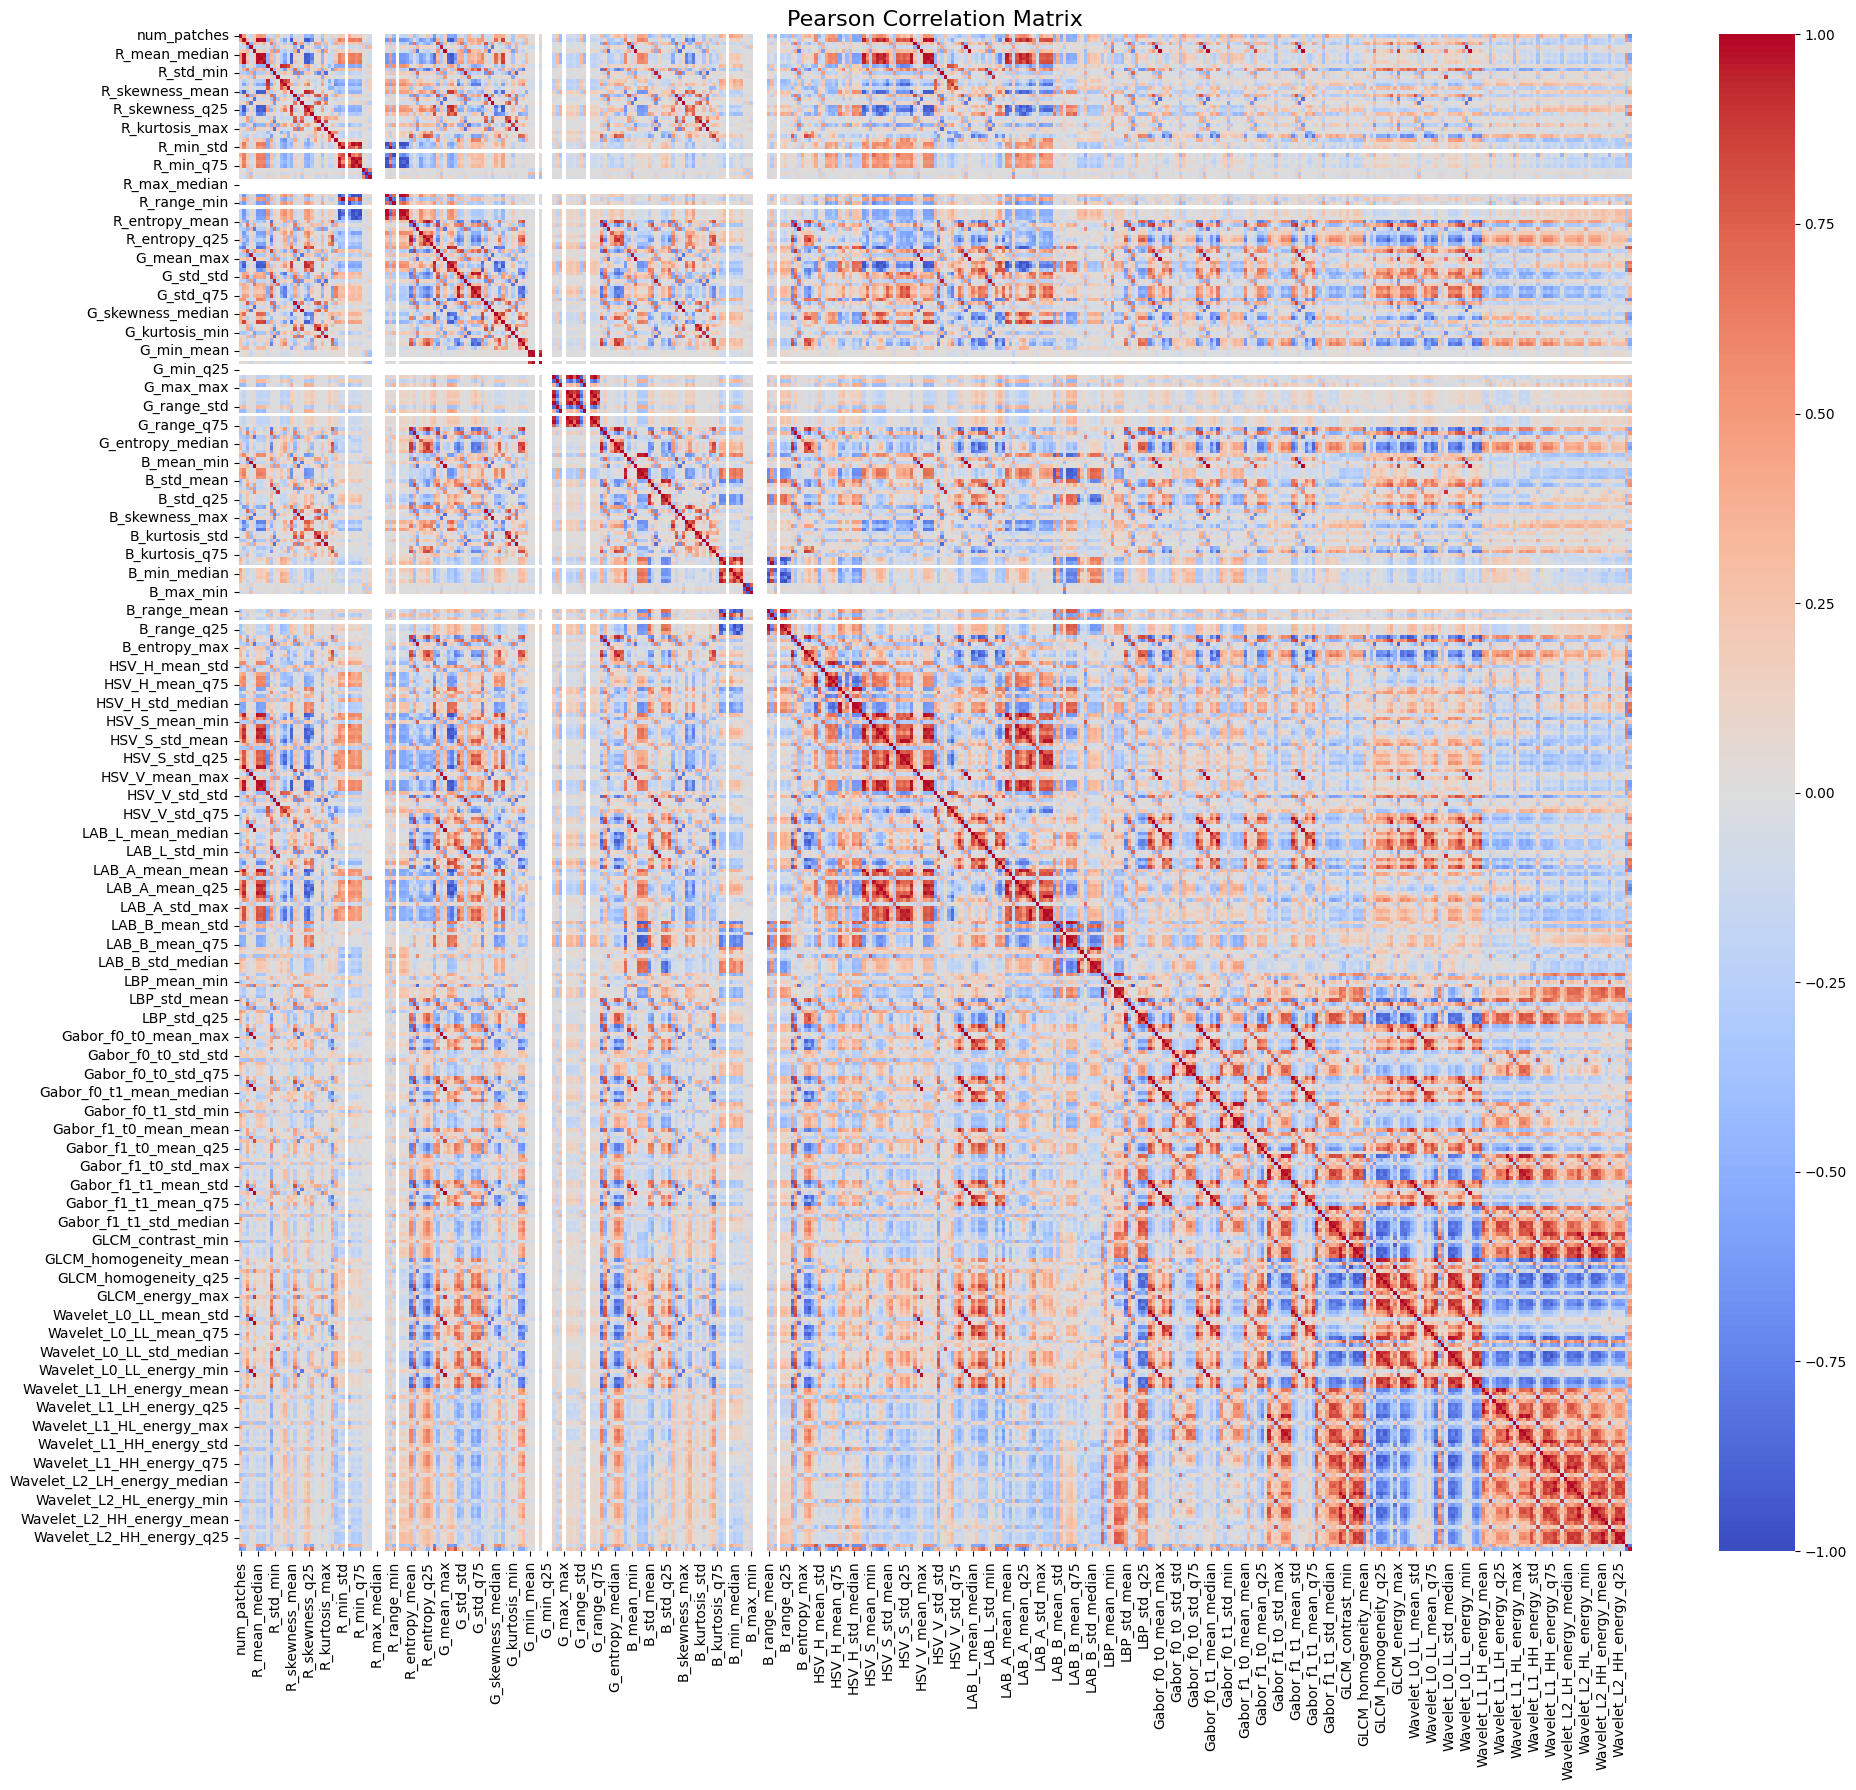

In [33]:
# Visualize a heatmap to display correlation matrix.

numeric_df = all_wsi.select_dtypes(include=["number"])

plt.figure(figsize=(20, 18))
corr_matrix_pearson = numeric_df.corr(method='pearson')
sns.heatmap(corr_matrix_pearson,
           annot=False,  # Remove annotations!
           cmap='coolwarm',
           linewidths=0)  # Remove gridlines too
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

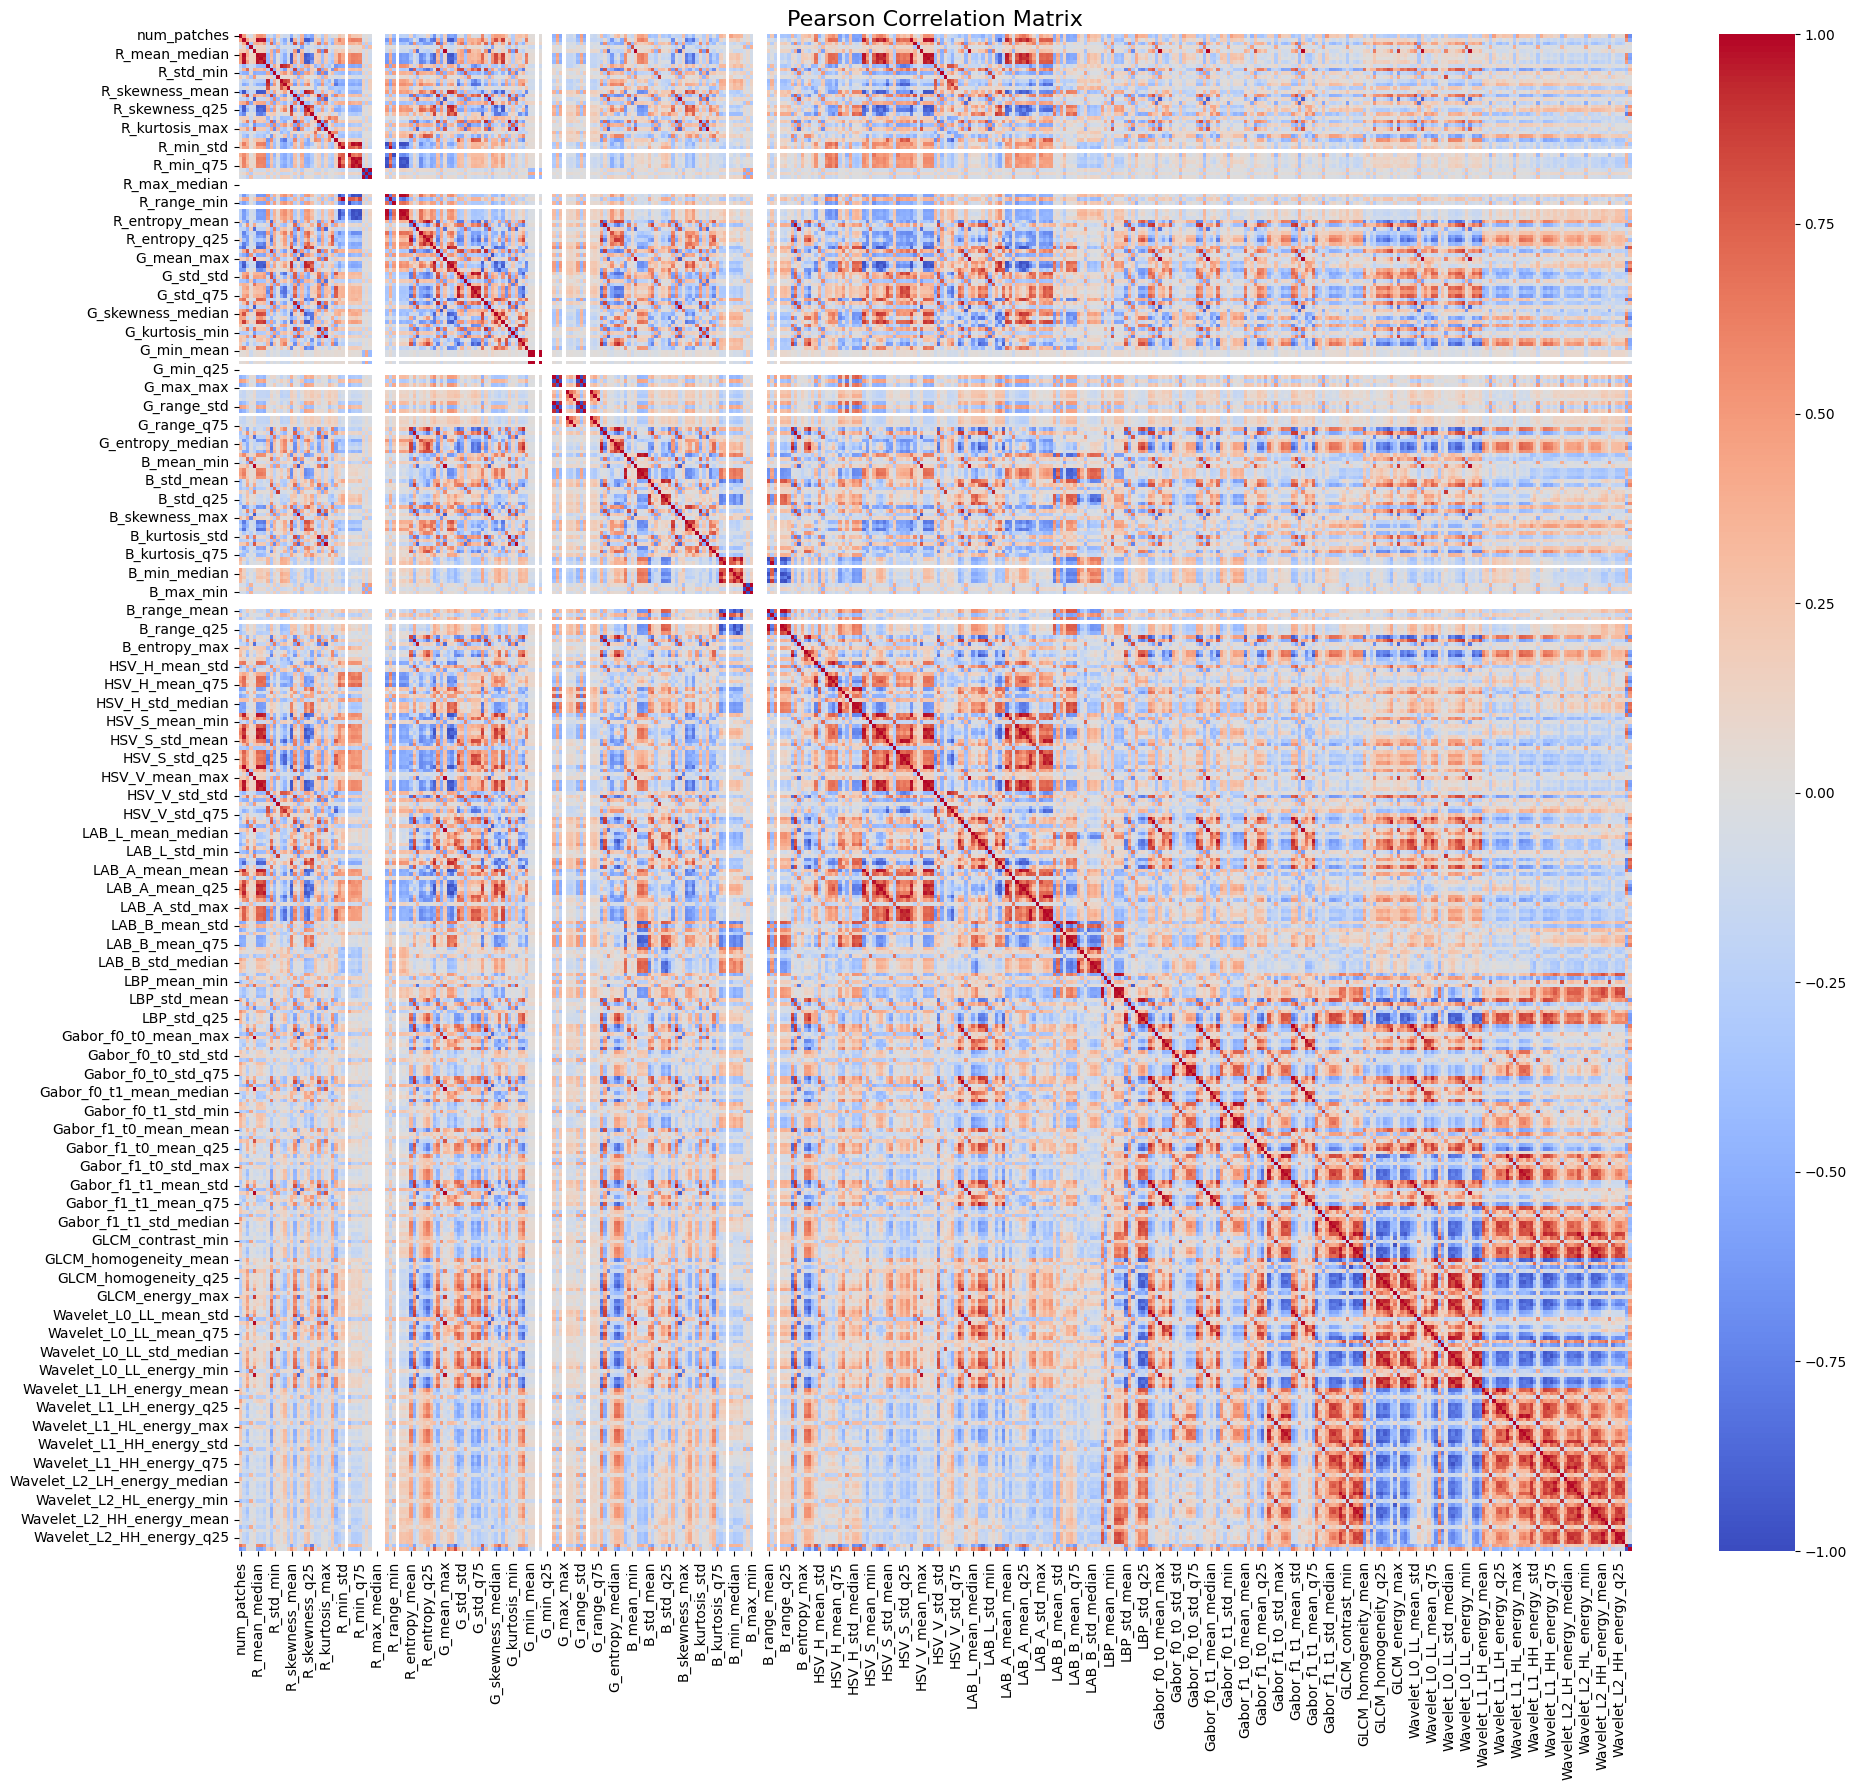

In [34]:
plt.figure(figsize=(20, 18))
corr_matrix_pearson = numeric_df.corr(method='spearman')
sns.heatmap(corr_matrix_pearson,
           annot=False,  # Remove annotations!
           cmap='coolwarm',
           linewidths=0)  # Remove gridlines too
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### Drop redundant columns

In [35]:
import pandas as pd
import numpy as np

# Create a list of columns to drop based on suffixes
columns_to_drop = []

for col in all_wsi.columns:
    if col.endswith('_min') or col.endswith('_max') or col.endswith('_q25') or col.endswith('_q75'):
        columns_to_drop.append(col)

# Display what will be dropped
print(f"Total columns to drop: {len(columns_to_drop)}")
print(f"\nFirst 10 columns to be dropped:")
print(columns_to_drop[:10])
print(f"\nLast 10 columns to be dropped:")
print(columns_to_drop[-10:])

# Drop the columns
all_wsi_reduced = all_wsi.drop(columns=columns_to_drop)

# Show results
print(f"\n{'='*60}")
print(f"RESULTS:")
print(f"{'='*60}")
print(f"Original columns: {all_wsi.shape[1]}")
print(f"Dropped columns: {len(columns_to_drop)}")
print(f"Remaining columns: {all_wsi_reduced.shape[1]}")
print(f"Original rows: {all_wsi.shape[0]}")
print(f"Remaining rows: {all_wsi_reduced.shape[0]}")
print(f"\nReduction: {len(columns_to_drop)/all_wsi.shape[1]*100:.1f}% of columns removed")

Total columns to drop: 232

First 10 columns to be dropped:
['R_mean_min', 'R_mean_max', 'R_mean_q25', 'R_mean_q75', 'R_std_min', 'R_std_max', 'R_std_q25', 'R_std_q75', 'R_skewness_min', 'R_skewness_max']

Last 10 columns to be dropped:
['Wavelet_L2_LH_energy_q25', 'Wavelet_L2_LH_energy_q75', 'Wavelet_L2_HL_energy_min', 'Wavelet_L2_HL_energy_max', 'Wavelet_L2_HL_energy_q25', 'Wavelet_L2_HL_energy_q75', 'Wavelet_L2_HH_energy_min', 'Wavelet_L2_HH_energy_max', 'Wavelet_L2_HH_energy_q25', 'Wavelet_L2_HH_energy_q75']

RESULTS:
Original columns: 413
Dropped columns: 232
Remaining columns: 181
Original rows: 546
Remaining rows: 546

Reduction: 56.2% of columns removed


In [36]:
all_wsi_reduced.columns.tolist()

['slide_name',
 'num_patches',
 'R_mean_mean',
 'R_mean_std',
 'R_mean_median',
 'R_std_mean',
 'R_std_std',
 'R_std_median',
 'R_skewness_mean',
 'R_skewness_std',
 'R_skewness_median',
 'R_kurtosis_mean',
 'R_kurtosis_std',
 'R_kurtosis_median',
 'R_min_mean',
 'R_min_std',
 'R_min_median',
 'R_max_mean',
 'R_max_std',
 'R_max_median',
 'R_range_mean',
 'R_range_std',
 'R_range_median',
 'R_entropy_mean',
 'R_entropy_std',
 'R_entropy_median',
 'G_mean_mean',
 'G_mean_std',
 'G_mean_median',
 'G_std_mean',
 'G_std_std',
 'G_std_median',
 'G_skewness_mean',
 'G_skewness_std',
 'G_skewness_median',
 'G_kurtosis_mean',
 'G_kurtosis_std',
 'G_kurtosis_median',
 'G_min_mean',
 'G_min_std',
 'G_min_median',
 'G_max_mean',
 'G_max_std',
 'G_max_median',
 'G_range_mean',
 'G_range_std',
 'G_range_median',
 'G_entropy_mean',
 'G_entropy_std',
 'G_entropy_median',
 'B_mean_mean',
 'B_mean_std',
 'B_mean_median',
 'B_std_mean',
 'B_std_std',
 'B_std_median',
 'B_skewness_mean',
 'B_skewness_std

def remove_correlated_features(all_wsi, threshold=0.95):
    """
    Remove features with correlation above threshold
    """
    # Calculate correlation matrix
    corr_matrix = all_wsi.corr().abs()
    
    # Get upper triangle of correlation matrix
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find columns with correlation > threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Drop the columns
    df_reduced = all_wsi.drop(columns=to_drop)
    
    print(f"Original features: {all_wsi.shape[1]}")
    print(f"Features after removal: {df_reduced.shape[1]}")
    print(f"Dropped {len(to_drop)} features")
    
    return df_reduced, to_drop

# Use it
numeric_df_reduced, dropped_cols = remove_correlated_features(numeric_df, threshold=0.95)

# See which columns were dropped
print("\nDropped columns:")
print(dropped_cols)

In [ ]:
# Drop G_max_median,R_max_median,B_max_median
cols = ['G_max_median', 'B_max_median', 'R_max_median','G_min_median']
all_wsi_reduced = all_wsi_reduced.drop(columns=cols)

In [ ]:
#numeric_df_reduced

In [ ]:
numeric=all_wsi_reduced.select_dtypes(include=["number"])
plt.figure(figsize=(20, 18))
corr_matrix_pearson = numeric.corr(method='spearman')
sns.heatmap(corr_matrix_pearson,
           annot=False,  # Remove annotations!
           cmap='coolwarm',
           linewidths=0)  # Remove gridlines too
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
numeric=all_wsi_reduced.select_dtypes(include=["number"])
plt.figure(figsize=(20, 18))
corr_matrix_pearson = numeric.corr(method='spearman')
sns.heatmap(corr_matrix_pearson,
           annot=False,  # Remove annotations!
           cmap='coolwarm',
           linewidths=0)  # Remove gridlines too
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
all_wsi_reduced.columns.tolist()

### Further dimension reduction with Random forest

In [ ]:
# ============================================================================
# LOAD YOUR DATA HERE
# ============================================================================
# 
# IMPORTANT: Replace this with your actual data loading code
# Your dataframe should be named 'all_wsi_reduced'
# It should contain features + a 'clinical_groups' target column
#

# EXAMPLE: If loading from CSV
# all_wsi_reduced = pd.read_csv('your_data.csv')

# Placeholder - REMOVE THIS LINE AND LOAD YOUR ACTUAL DATA
# all_wsi_reduced = pd.read_csv('your_actual_data.csv')

#print("Data loaded successfully")
print(f"Data shape: {all_wsi_reduced.shape}")
print(f"Columns: {all_wsi_reduced.columns.tolist()[:10]}...")

#### Data Preparation (Before Split)

In [ ]:
# ============================================================================
# STEP 1: PREPARE DATA (BEFORE SPLITTING)
# ============================================================================

print("\n" + "="*70)
print("STEP 1: DATA PREPARATION (BEFORE SPLIT)")
print("="*70)

# Remove identifiers and zero-variance columns (safe to do before split)
print("\n1.1 Removing non-feature columns...")
non_features = ['slide_name', 'num_patches', 'clinical_groups', 'slide_number']
existing_non_features = [col for col in all_wsi_reduced.columns if col in non_features]

if existing_non_features:
    all_wsi_cleaned = all_wsi_reduced.drop(columns=existing_non_features)
    print(f"    Dropped: {existing_non_features}")
else:
    all_wsi_cleaned = all_wsi_reduced.copy()
    print(f"    No non-feature columns found")

# Separate features and target
X = all_wsi_cleaned.drop(columns=['source'])
y = all_wsi_cleaned['source']

print(f"\n1.2 Initial dataset:")
print(f"    Total samples: {len(X)}")
print(f"    Total features: {X.shape[1]}")
print(f"    Target classes: {y.value_counts().to_dict()}")

# Remove zero/near-zero variance features (safe before split)
print("\n1.3 Removing zero/near-zero variance features...")
zero_var_cols = []
for col in X.columns:
    if X[col].std() < 0.01:  # variance threshold
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"    Found {len(zero_var_cols)} low-variance features")
    print(f"    Examples: {zero_var_cols[:5]}")
    X = X.drop(columns=zero_var_cols)
else:
    print("    No zero-variance features found")

print(f"    Remaining features: {X.shape[1]}")

In [ ]:
all_wsi_reduced[['R_max_mean', 'G_min_mean', 'G_min_std']]

#### Train-Test Split

In [ ]:
# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (PREVENT LEAKAGE!)
# ============================================================================

print("\n" + "="*70)
print("STEP 2: TRAIN-TEST SPLIT (80/20)")
print("="*70)

# Split data - stratify to keep class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Keep same class proportions in train/test
)

print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

# Store original feature count for later
original_feature_count = X_train.shape[1]

#### Random Forest Feature Importance

In [ ]:
# ============================================================================
# STEP 3.1: METHOD 1 - RANDOM FOREST FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*70)
print("STEP 3.1: Random Forest Feature Importance (TRAIN SET ONLY)")
print("="*70)

print("\n3.1 Training Random Forest on TRAIN SET ONLY...")
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"  # Handle class imbalance
)

rf_model.fit(X_train, y_train)
print("    ✓ Random Forest trained")

# Get feature importances from TRAIN set only
rf_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Convert to percentage
total = rf_importances['importance'].sum()
rf_importances['importance_pct'] = 100 * rf_importances['importance'] / total

# Sort by %
rf_importances = rf_importances.sort_values(
    'importance_pct',
    ascending=False
)


for _, row in rf_importances.head(10).iterrows():
    print(f"{row['feature']:<40} {row['importance_pct']:.2f}%")

# Store the trained model for later use
rf_trained_model = rf_model

In [ ]:
rf_trained_model.score(X_train, y_train)

#### LightGBM Feature Importance

In [ ]:
rf_trained_model.score(X_train, y_train)


In [ ]:
# ============================================================================
# STEP 3.2: METHOD 2 - LIGHTGBM FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*70)
print("STEP 3.2: LightGBM Feature Importance (TRAIN SET ONLY)")
print("="*70)

print("\n3.2 Training LightGBM on TRAIN SET ONLY...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.03,
    min_child_samples=60,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=3.0,
    reg_lambda=3.0,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbosity=-1
)

lgb_model.fit(X_train, y_train)
print("    ✓ LightGBM trained")

lgb_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
})

# Convert to percentage
total = lgb_importances['importance'].sum()
lgb_importances['importance_pct'] = 100 * lgb_importances['importance'] / total

# Sort after computing %
lgb_importances = lgb_importances.sort_values(
    'importance_pct',
    ascending=False
)

for _, row in lgb_importances.head(10).iterrows():
    print(f"{row['feature']:<40} {row['importance_pct']:.2f}%")


In [ ]:
train_score = lgb_model.score(X_train, y_train)
#val_score   = lgb_model.score(X_val, y_val)

print(train_score)
#print(val_score)

#### Permutation Importance

In [ ]:
# ============================================================================
# STEP 3.3: METHOD 3 - PERMUTATION IMPORTANCE
# ============================================================================

print("\n" + "="*70)
print("STEP 3.3: Permutation Importance (TRAIN SET ONLY)")
print("="*70)

print("\n3.3 Calculating Permutation Importance on TRAIN SET ONLY...")
print("    (This may take a few minutes...)")

perm_importance = permutation_importance(
    rf_trained_model,  # Use the already trained Random Forest
    X_train, 
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print(f"\n    Top 10 features (Permutation Importance):")
for idx, row in perm_importances.head(10).iterrows():
    print(f"      {row['feature']:<40} {row['importance']:.4f} ± {row['std']:.4f}")

#### Combine Rankings and Select Top Features

In [ ]:
# ============================================================================
# STEP 4: SELECT TOP FEATURES (ENSEMBLE APPROACH)
# ============================================================================

print("\n" + "="*70)
print("STEP 4: SELECT TOP FEATURES")
print("="*70)

# Choose how many features to keep - ADJUST THIS VALUE!
N_FEATURES = 50  # Change this based on your needs

print(f"\n4.1 Combining feature rankings from all 3 methods...")
print(f"    Keeping top {N_FEATURES} features")

# Normalize importance scores to 0-1 range
rf_importances['normalized'] = (rf_importances['importance'] - rf_importances['importance'].min()) / \
                                (rf_importances['importance'].max() - rf_importances['importance'].min())
lgb_importances['normalized'] = (lgb_importances['importance'] - lgb_importances['importance'].min()) / \
                                 (lgb_importances['importance'].max() - lgb_importances['importance'].min())
perm_importances['normalized'] = (perm_importances['importance'] - perm_importances['importance'].min()) / \
                                  (perm_importances['importance'].max() - perm_importances['importance'].min())

# Average the rankings
combined_importance = pd.DataFrame({'feature': X_train.columns})
combined_importance = combined_importance.merge(
    rf_importances[['feature', 'normalized']].rename(columns={'normalized': 'rf_score'}),
    on='feature'
).merge(
    lgb_importances[['feature', 'normalized']].rename(columns={'normalized': 'lgb_score'}),
    on='feature'
).merge(
    perm_importances[['feature', 'normalized']].rename(columns={'normalized': 'perm_score'}),
    on='feature'
)

# Calculate average score
combined_importance['avg_score'] = (
    combined_importance['rf_score'] + 
    combined_importance['lgb_score'] + 
    combined_importance['perm_score']
) / 3

combined_importance = combined_importance.sort_values('avg_score', ascending=False)

print(f"\n4.2 Top {N_FEATURES} features (Combined Rankings):")
top_features = combined_importance.head(N_FEATURES)
for idx, row in top_features.head(50).iterrows():
    print(f"      {row['feature']:<40} {row['avg_score']:.4f}")

# Get list of selected features
selected_features = top_features['feature'].tolist()

In [ ]:
# ============================================================================
# STEP 5: CREATE REDUCED DATASETS (APPLY TO BOTH TRAIN AND TEST)
# ============================================================================

print("\n" + "="*70)
print("STEP 5: APPLY FEATURE SELECTION TO TRAIN AND TEST SETS")
print("="*70)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")
print(f"Reduction: {(1 - X_train_selected.shape[1]/X_train.shape[1])*100:.1f}%")

print(f"\nTrain set: {X_train_selected.shape}")
print(f"Test set:  {X_test_selected.shape}")

In [ ]:
# ============================================================================
# STEP 6: VALIDATE FEATURE SELECTION (COMPARE PERFORMANCE)
# ============================================================================

print("\n" + "="*70)
print("STEP 6: VALIDATE FEATURE SELECTION")
print("="*70)

print("\n6.1 Training models with ALL features...")
rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)
score_all = accuracy_score(y_test, y_pred_all)
print(f"    Test Accuracy (ALL {X_train.shape[1]} features): {score_all:.4f}")

print(f"\n6.2 Training models with TOP {N_FEATURES} features...")
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)
score_selected = accuracy_score(y_test, y_pred_selected)
print(f"    Test Accuracy (TOP {N_FEATURES} features): {score_selected:.4f}")

print(f"\n    Performance difference: {(score_selected - score_all)*100:+.2f}%")

if score_selected >= score_all * 0.95:
    print(f"    ✓ Feature selection successful! (Within 5% of full model)")
else:
    print(f"    ⚠ Consider keeping more features")

# ============================================================================
# STEP 6: VALIDATE FEATURE SELECTION - COMPARE MULTIPLE THRESHOLDS
# ============================================================================

print("\n" + "="*70)
print("STEP 6: VALIDATE FEATURE SELECTION - MULTIPLE THRESHOLDS")
print("="*70)

# Define feature thresholds to evaluate
FEATURE_THRESHOLDS = [30, 50, 80]
results = {}

# ----------------------------------------------------------------------------
# 6.1 Baseline: Model with ALL features
# ----------------------------------------------------------------------------
print("\n" + "-"*70)
print("6.1 BASELINE: ALL FEATURES")
print("-"*70)

rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)
score_all = accuracy_score(y_test, y_pred_all)
print(f"    Test Accuracy (ALL {X_train.shape[1]} features): {score_all:.4f}")

results['all'] = {
    'n_features': X_train.shape[1],
    'accuracy': score_all,
    'model': rf_all
}

# ----------------------------------------------------------------------------
# 6.2 Evaluate each feature threshold
# ----------------------------------------------------------------------------
print("\n" + "-"*70)
print("6.2 EVALUATING DIFFERENT FEATURE COUNTS")
print("-"*70)

for n_features in FEATURE_THRESHOLDS:
    print(f"\n    ▶ Top {n_features} features:")
    
    # Get top N features from combined importance
    top_n_features = combined_importance.head(n_features)['feature'].tolist()
    
    # Create reduced datasets
    X_train_top_n = X_train[top_n_features]
    X_test_top_n = X_test[top_n_features]
    
    # Train and evaluate
    rf_top_n = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_top_n.fit(X_train_top_n, y_train)
    y_pred_top_n = rf_top_n.predict(X_test_top_n)
    score_top_n = accuracy_score(y_test, y_pred_top_n)
    
    # Calculate difference from baseline
    diff = (score_top_n - score_all) * 100
    
    # Store results
    results[n_features] = {
        'n_features': n_features,
        'accuracy': score_top_n,
        'difference': diff,
        'model': rf_top_n,
        'X_train': X_train_top_n,
        'X_test': X_test_top_n,
        'features': top_n_features
    }
    
    # Print results with formatting
    print(f"      Accuracy: {score_top_n:.4f}")
    print(f"      Difference: {diff:+.2f}%")
    
    # Status indicator
    if score_top_n >= score_all * 0.95:
        print(f"      ✓ Within 5% of full model")
    elif score_top_n >= score_all * 0.90:
        print(f"      ⚡ Within 10% of full model")
    else:
        print(f"      ⚠ Performance drop >10%")

# ----------------------------------------------------------------------------
# 6.3 Summary Comparison Table
# ----------------------------------------------------------------------------
print("\n" + "-"*70)
print("6.3 PERFORMANCE COMPARISON SUMMARY")
print("-"*70)

print(f"\n{'Features':<15} {'Accuracy':<15} {'vs All':<15} {'Reduction':<15} {'Status':<15}")
print(f"{'-'*75}")

# All features row
print(f"{'ALL':<15} {score_all:.4f}{' ':<11} {'-':<15} {'0%':<15} {'baseline':<15}")

# Each threshold
for n_features in FEATURE_THRESHOLDS:
    res = results[n_features]
    reduction = (1 - res['n_features']/X_train.shape[1]) * 100
    
    # Status label
    if res['accuracy'] >= score_all * 0.95:
        status = "✓ GOOD"
    elif res['accuracy'] >= score_all * 0.90:
        status = "⚡ OK"
    else:
        status = "⚠ POOR"
    
    print(f"{n_features:<15} {res['accuracy']:.4f}{' ':<11} {res['difference']:+.2f}%{' ':<11} {reduction:.1f}%{' ':<11} {status:<15}")

# ----------------------------------------------------------------------------
# 6.4 Visual Comparison
# ----------------------------------------------------------------------------
print("\n" + "-"*70)
print("6.4 VISUAL COMPARISON")
print("-"*70)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
thresholds = ['ALL'] + [str(t) for t in FEATURE_THRESHOLDS]
accuracies = [score_all] + [results[t]['accuracy'] for t in FEATURE_THRESHOLDS]
colors = ['#2E86AB'] + ['#A23B72' if acc < score_all * 0.95 else '#F3B562' if acc < score_all else '#2E86AB' for acc in accuracies[1:]]

bars1 = ax1.bar(thresholds, accuracies, color=colors)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Performance by Feature Count')
ax1.set_ylim([min(accuracies) - 0.05, max(accuracies) + 0.05])

# Add value labels on bars
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# Add baseline reference line
ax1.axhline(y=score_all, color='red', linestyle='--', alpha=0.5, label='All features')
ax1.axhline(y=score_all * 0.95, color='orange', linestyle='--', alpha=0.5, label='95% threshold')
ax1.legend()

# Plot 2: Feature reduction vs performance
n_features_list = [results[t]['n_features'] for t in FEATURE_THRESHOLDS]
reductions = [(1 - n/X_train.shape[1]) * 100 for n in n_features_list]
performance_drops = [(score_all - results[t]['accuracy']) * 100 for t in FEATURE_THRESHOLDS]

ax2.scatter(reductions, performance_drops, s=100)
for i, txt in enumerate(FEATURE_THRESHOLDS):
    ax2.annotate(f'Top {txt}', (reductions[i], performance_drops[i]), 
                 xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Feature Reduction (%)')
ax2.set_ylabel('Performance Drop (%)')
ax2.set_title('Trade-off: Feature Reduction vs Performance')
ax2.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(reductions, performance_drops, 1)
p = np.poly1d(z)
ax2.plot(reductions, p(reductions), "r--", alpha=0.5)

plt.tight_layout()
plt.savefig('feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: feature_selection_comparison.png")

# ----------------------------------------------------------------------------
# 6.5 Recommendation
# ----------------------------------------------------------------------------
print("\n" + "-"*70)
print("6.5 RECOMMENDATION")
print("-"*70)

# Find best performing threshold (closest to all features performance)
best_threshold = min(FEATURE_THRESHOLDS, 
                    key=lambda x: abs(score_all - results[x]['accuracy']))

# Find most efficient threshold (best accuracy with fewest features)
efficient_threshold = min(FEATURE_THRESHOLDS,
                        key=lambda x: (1 - results[x]['accuracy']/score_all) * 100 / results[x]['n_features'])

print(f"\nBased on {len(FEATURE_THRESHOLDS)} evaluated thresholds:")

print(f"\n  Best Performance: Top {best_threshold} features")
print(f"    - Accuracy: {results[best_threshold]['accuracy']:.4f}")
print(f"    - Difference: {results[best_threshold]['difference']:+.2f}%")
print(f"    - Reduction: {(1 - results[best_threshold]['n_features']/X_train.shape[1])*100:.1f}%")

print(f"\n  Most Efficient: Top {efficient_threshold} features")
print(f"    - Accuracy: {results[efficient_threshold]['accuracy']:.4f}")
print(f"    - Features saved per 1% performance drop: {(1 - results[efficient_threshold]['n_features']/X_train.shape[1])*100 / max(0.1, abs(results[efficient_threshold]['difference'])):.1f}")

# Store the best model for downstream tasks
if results[best_threshold]['accuracy'] >= score_all * 0.95:
    print(f"\n  ✓ RECOMMENDED: Use Top {best_threshold} features")
    recommended_n = best_threshold
else:
    print(f"\n  ⚠ Consider evaluating more features (100, 150, etc.)")
    recommended_n = max(FEATURE_THRESHOLDS)

# ----------------------------------------------------------------------------
# 6.6 Set final selected features based on recommendation
# ----------------------------------------------------------------------------
print("\n" + "-"*70)
print("6.6 FINAL SELECTED FEATURES")
print("-"*70)

# You can change this to use any threshold you prefer
FINAL_N_FEATURES = recommended_n  # Automatically picks recommended, or override manually

print(f"\nUsing Top {FINAL_N_FEATURES} features for downstream analysis:")

final_features = combined_importance.head(FINAL_N_FEATURES)['feature'].tolist()
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

print(f"  ✓ X_train_final shape: {X_train_final.shape}")
print(f"  ✓ X_test_final shape: {X_test_final.shape}")
print(f"  ✓ Feature reduction: {(1 - X_train_final.shape[1]/X_train.shape[1])*100:.1f}%")

#### Visualizations - Feature Importance Comparison

In [ ]:
# ============================================================================
# STEP 7.1: VISUALIZATIONS - FEATURE IMPORTANCE COMPARISON
# ============================================================================

print("\n" + "="*70)
print("STEP 7.1: CREATING FEATURE IMPORTANCE VISUALIZATIONS")
print("="*70)

# Plot 1: Top 30 features comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Random Forest
top_30_rf = rf_importances.head(30)
axes[0, 0].barh(range(len(top_30_rf)), top_30_rf['importance'])
axes[0, 0].set_yticks(range(len(top_30_rf)))
axes[0, 0].set_yticklabels(top_30_rf['feature'], fontsize=8)
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Top 30 Features - Random Forest')
axes[0, 0].invert_yaxis()

# LightGBM
top_30_lgb = lgb_importances.head(30)
axes[0, 1].barh(range(len(top_30_lgb)), top_30_lgb['importance'])
axes[0, 1].set_yticks(range(len(top_30_lgb)))
axes[0, 1].set_yticklabels(top_30_lgb['feature'], fontsize=8)
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Top 30 Features - LightGBM')
axes[0, 1].invert_yaxis()

# Permutation Importance
top_30_perm = perm_importances.head(30)
axes[1, 0].barh(range(len(top_30_perm)), top_30_perm['importance'])
axes[1, 0].set_yticks(range(len(top_30_perm)))
axes[1, 0].set_yticklabels(top_30_perm['feature'], fontsize=8)
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Top 30 Features - Permutation Importance')
axes[1, 0].invert_yaxis()

# Combined
top_30_combined = combined_importance.head(30)
axes[1, 1].barh(range(len(top_30_combined)), top_30_combined['avg_score'])
axes[1, 1].set_yticks(range(len(top_30_combined)))
axes[1, 1].set_yticklabels(top_30_combined['feature'], fontsize=8)
axes[1, 1].set_xlabel('Average Score')
axes[1, 1].set_title(f'Top 30 Features - Combined (FINAL SELECTION)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: feature_importance_comparison.png")

#### Visualizations - Feature Group Breakdown

In [ ]:
# ============================================================================
# STEP 7.2: VISUALIZATIONS - FEATURE GROUP BREAKDOWN
# ============================================================================

print("\n" + "="*70)
print("STEP 7.2: ANALYZING SELECTED FEATURES BY GROUP")
print("="*70)

print("\n7.1 Analyzing selected features by group...")

# Define feature groups based on naming conventions
# ADJUST THESE PATTERNS TO MATCH YOUR ACTUAL FEATURE NAMES!
feature_groups = {
    'RGB': len([f for f in selected_features if any(f.startswith(p) for p in ('R_', 'G_', 'B_', 'rgb_'))]),
    'HSV': len([f for f in selected_features if f.startswith(('HSV_', 'hsv_'))]),
    'LAB': len([f for f in selected_features if f.startswith(('LAB_', 'lab_'))]),
    'LBP': len([f for f in selected_features if f.startswith(('LBP_', 'lbp_'))]),
    'Gabor': len([f for f in selected_features if f.startswith(('Gabor_', 'gabor_'))]),
    'GLCM': len([f for f in selected_features if f.startswith(('GLCM_', 'glcm_'))]),
    'Wavelet': len([f for f in selected_features if f.startswith(('Wavelet_', 'wavelet_'))]),
    'Tissue': len([f for f in selected_features if f.startswith(('tissue_', 'tissue_'))]),
    'Other': 0  # Will count features that don't match any group
}

# Calculate 'Other' category
all_matched = sum([v for k, v in feature_groups.items() if k != 'Other'])
feature_groups['Other'] = len(selected_features) - all_matched

# Remove groups with zero features
feature_groups = {k: v for k, v in feature_groups.items() if v > 0}

plt.figure(figsize=(10, 6))
bars = plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel('Feature Group')
plt.ylabel('Number of Selected Features')
plt.title(f'Selected Features by Group (Top {N_FEATURES} Total)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_groups_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: feature_groups_breakdown.png")
print("\nFeature group breakdown:")
for group, count in feature_groups.items():
    print(f"  {group:<10} {count:>3} features ({count/N_FEATURES*100:.1f}%)")

# Level-One Training

In [ ]:
# Set weight as the for the model as
#class_weights = {0: 1, 1: len(y_train[y_train==0]) / len(y_train[y_train==1])}

# Define the model
# Use the calculated weight for the positive class (dropout, which is class 1)
#xg_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=class_weights[1])
xg_model = xgb.XGBClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'learning_rate': [0.1, 0.2, 0.5],
    'max_depth': [5, 7, 10],
    'n_estimators': [200, 300, 500]
}

# Perform grid search
# Changed scoring to 'f1' as it's often more relevant for imbalanced datasets than just 'recall'
grid_search = GridSearchCV(xg_model, param_grid, scoring='recall', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test data
best_xg_model = grid_search.best_estimator_
predictions_xgb_tuned_1 = best_xg_model.predict(X_test)

print('XGBoost Classifier Performance')
print('Accuracy:', accuracy_score(y_test, predictions_xgb_tuned_1))
print('Precision:', precision_score(y_test, predictions_xgb_tuned_1))
print('Recall:', recall_score(y_test, predictions_xgb_tuned_1))
print('F1 Score:', f1_score(y_test, predictions_xgb_tuned_1))
print('AUC-ROC:', roc_auc_score(y_test, predictions_xgb_tuned_1))

print(classification_report(y_test, predictions_xgb_tuned_1))

# Confusion matrix
cm = confusion_matrix(y_test, predictions_xgb_tuned_1)
cfmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pathological Benign", "Ductal Carcinoma In Situ",
       "Invasive Carcinoma", "Atypical Ductal Hyperplasia",
       "Usual Ductal Hyperplasia", "Flat Epithelial Atypia", "Normal"])
cfmd.plot()
plt.show()

In [ ]:
from xgboost import XGBClassifier
import xgboost as xgb

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [ ]:
all_wsi["source"].unique()

print("="*70)
print("MODEL-BASED FEATURE SELECTION PIPELINE")
print("="*70)

# ============================================================================
# STEP 1: PREPARE DATA (BEFORE SPLITTING)
# ============================================================================
print("\n" + "="*70)
print("STEP 1: DATA PREPARATION (BEFORE SPLIT)")
print("="*70)

# Remove identifiers and zero-variance columns (safe to do before split)
print("\n1.1 Removing non-feature columns...")
non_features = ['slide_name', 'num_patches', 'source','slide_number']
existing_non_features = [col for col in all_wsi_reduced.columns if col in non_features]
if existing_non_features:
    all_wsi_cleaned = all_wsi_reduced.drop(columns=existing_non_features)
    print(f"    Dropped: {existing_non_features}")

# Separate features and target
X = all_wsi_cleaned.drop(columns=['clinical_groups'])
y = all_wsi_cleaned['clinical_groups']

print(f"\n1.2 Initial dataset:")
print(f"    Total samples: {len(X)}")
print(f"    Total features: {X.shape[1]}")
print(f"    Target classes: {y.value_counts().to_dict()}")

# Remove zero/near-zero variance features (safe before split)
print("\n1.3 Removing zero/near-zero variance features...")
zero_var_cols = []
for col in X.columns:
    if X[col].std() < 0.01:  # variance threshold
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"    Found {len(zero_var_cols)} low-variance features")
    print(f"    Examples: {zero_var_cols[:5]}")
    X = X.drop(columns=zero_var_cols)
else:
    print("    No zero-variance features found")

print(f"    Remaining features: {X.shape[1]}")

# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (PREVENT LEAKAGE!)
# ============================================================================
print("\n" + "="*70)
print("STEP 2: TRAIN-TEST SPLIT (80/20)")
print("="*70)

# Split data - stratify to keep class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Keep same class proportions in train/test
)

print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

# ============================================================================
# STEP 3: FEATURE SELECTION ON TRAINING DATA ONLY
# ============================================================================
print("\n" + "="*70)
print("STEP 3: FEATURE SELECTION (TRAIN SET ONLY - NO LEAKAGE!)")
print("="*70)

# ──────────────────────────────────────────────────────────────────────────
# Method 1: Random Forest Feature Importance
# ──────────────────────────────────────────────────────────────────────────
print("\n3.1 Training Random Forest on TRAIN SET ONLY...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

rf_model.fit(X_train, y_train)
print("    ✓ Random Forest trained")

# Get feature importances from TRAIN set only
rf_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n    Top 10 features (Random Forest):")
for idx, row in rf_importances.head(10).iterrows():
    print(f"      {row['feature']:<40} {row['importance']:.4f}")

# ──────────────────────────────────────────────────────────────────────────
# Method 2: LightGBM Feature Importance (Often better for tabular data)
# ──────────────────────────────────────────────────────────────────────────
print("\n3.2 Training LightGBM on TRAIN SET ONLY...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbosity=-1
)

lgb_model.fit(X_train, y_train)
print("    ✓ LightGBM trained")

lgb_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n    Top 10 features (LightGBM):")
for idx, row in lgb_importances.head(10).iterrows():
    print(f"      {row['feature']:<40} {row['importance']:.4f}")

# ──────────────────────────────────────────────────────────────────────────
# Method 3: Permutation Importance (Most Reliable)
# ──────────────────────────────────────────────────────────────────────────
print("\n3.3 Calculating Permutation Importance on TRAIN SET ONLY...")
print("    (This may take a few minutes...)")

perm_importance = permutation_importance(
    rf_model, 
    X_train, 
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print(f"\n    Top 10 features (Permutation Importance):")
for idx, row in perm_importances.head(10).iterrows():
    print(f"      {row['feature']:<40} {row['importance']:.4f} ± {row['std']:.4f}")

# ============================================================================
# STEP 4: SELECT TOP FEATURES
# ============================================================================
print("\n" + "="*70)
print("STEP 4: SELECT TOP FEATURES")
print("="*70)

# Choose how many features to keep
N_FEATURES = 50  # Adjust this based on your needs

# Combine rankings from all methods (ensemble approach)
print(f"\n4.1 Combining feature rankings from all 3 methods...")

# Normalize importance scores to 0-1 range
rf_importances['normalized'] = (rf_importances['importance'] - rf_importances['importance'].min()) / \
                                (rf_importances['importance'].max() - rf_importances['importance'].min())
lgb_importances['normalized'] = (lgb_importances['importance'] - lgb_importances['importance'].min()) / \
                                 (lgb_importances['importance'].max() - lgb_importances['importance'].min())
perm_importances['normalized'] = (perm_importances['importance'] - perm_importances['importance'].min()) / \
                                  (perm_importances['importance'].max() - perm_importances['importance'].min())

# Average the rankings
combined_importance = pd.DataFrame({'feature': X_train.columns})
combined_importance = combined_importance.merge(
    rf_importances[['feature', 'normalized']].rename(columns={'normalized': 'rf_score'}),
    on='feature'
).merge(
    lgb_importances[['feature', 'normalized']].rename(columns={'normalized': 'lgb_score'}),
    on='feature'
).merge(
    perm_importances[['feature', 'normalized']].rename(columns={'normalized': 'perm_score'}),
    on='feature'
)

# Calculate average score
combined_importance['avg_score'] = (
    combined_importance['rf_score'] + 
    combined_importance['lgb_score'] + 
    combined_importance['perm_score']
) / 3

combined_importance = combined_importance.sort_values('avg_score', ascending=False)

print(f"\n4.2 Top {N_FEATURES} features (Combined Rankings):")
top_features = combined_importance.head(N_FEATURES)
for idx, row in top_features.head(20).iterrows():
    print(f"      {row['feature']:<40} {row['avg_score']:.4f}")

# Get list of selected features
selected_features = top_features['feature'].tolist()

# ============================================================================
# STEP 5: CREATE REDUCED DATASETS (APPLY TO BOTH TRAIN AND TEST)
# ============================================================================
print("\n" + "="*70)
print("STEP 5: APPLY FEATURE SELECTION TO TRAIN AND TEST SETS")
print("="*70)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")
print(f"Reduction: {(1 - X_train_selected.shape[1]/X_train.shape[1])*100:.1f}%")

print(f"\nTrain set: {X_train_selected.shape}")
print(f"Test set:  {X_test_selected.shape}")

# ============================================================================
# STEP 6: VALIDATE FEATURE SELECTION (COMPARE PERFORMANCE)
# ============================================================================
print("\n" + "="*70)
print("STEP 6: VALIDATE FEATURE SELECTION")
print("="*70)

print("\n6.1 Training models with ALL features...")
rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_all.fit(X_train, y_train)
score_all = rf_all.score(X_test, y_test)
print(f"    Test Accuracy (ALL {X_train.shape[1]} features): {score_all:.4f}")

print(f"\n6.2 Training models with TOP {N_FEATURES} features...")
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_selected, y_train)
score_selected = rf_selected.score(X_test_selected, y_test)
print(f"    Test Accuracy (TOP {N_FEATURES} features): {score_selected:.4f}")

print(f"\n    Performance difference: {(score_selected - score_all)*100:+.2f}%")

if score_selected >= score_all * 0.95:
    print(f"    ✓ Feature selection successful! (Within 5% of full model)")
else:
    print(f"    ⚠ Consider keeping more features")

# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("STEP 7: CREATING VISUALIZATIONS")
print("="*70)

# Plot 1: Top 30 features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Random Forest
top_30_rf = rf_importances.head(30)
axes[0, 0].barh(range(len(top_30_rf)), top_30_rf['importance'])
axes[0, 0].set_yticks(range(len(top_30_rf)))
axes[0, 0].set_yticklabels(top_30_rf['feature'], fontsize=8)
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Top 30 Features - Random Forest')
axes[0, 0].invert_yaxis()

# LightGBM
top_30_lgb = lgb_importances.head(30)
axes[0, 1].barh(range(len(top_30_lgb)), top_30_lgb['importance'])
axes[0, 1].set_yticks(range(len(top_30_lgb)))
axes[0, 1].set_yticklabels(top_30_lgb['feature'], fontsize=8)
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Top 30 Features - LightGBM')
axes[0, 1].invert_yaxis()

# Permutation Importance
top_30_perm = perm_importances.head(30)
axes[1, 0].barh(range(len(top_30_perm)), top_30_perm['importance'])
axes[1, 0].set_yticks(range(len(top_30_perm)))
axes[1, 0].set_yticklabels(top_30_perm['feature'], fontsize=8)
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Top 30 Features - Permutation Importance')
axes[1, 0].invert_yaxis()

# Combined
top_30_combined = combined_importance.head(30)
axes[1, 1].barh(range(len(top_30_combined)), top_30_combined['avg_score'])
axes[1, 1].set_yticks(range(len(top_30_combined)))
axes[1, 1].set_yticklabels(top_30_combined['feature'], fontsize=8)
axes[1, 1].set_xlabel('Average Score')
axes[1, 1].set_title(f'Top 30 Features - Combined (FINAL SELECTION)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: feature_importance_comparison.png")

# Plot 2: Feature groups breakdown
print("\n7.1 Analyzing selected features by group...")
feature_groups = {
    'RGB': len([f for f in selected_features if f.startswith(('R_', 'G_', 'B_'))]),
    'HSV': len([f for f in selected_features if f.startswith('HSV_')]),
    'LAB': len([f for f in selected_features if f.startswith('LAB_')]),
    'LBP': len([f for f in selected_features if f.startswith('LBP_')]),
    'Gabor': len([f for f in selected_features if f.startswith('Gabor_')]),
    'GLCM': len([f for f in selected_features if f.startswith('GLCM_')]),
    'Wavelet': len([f for f in selected_features if f.startswith('Wavelet_')]),
    'Tissue': len([f for f in selected_features if f.startswith('tissue_')])
}

plt.figure(figsize=(10, 6))
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel('Feature Group')
plt.ylabel('Number of Selected Features')
plt.title(f'Selected Features by Group (Top {N_FEATURES} Total)')
plt.xticks(rotation=45)
for i, (k, v) in enumerate(feature_groups.items()):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_groups_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: feature_groups_breakdown.png")

print("\nFeature group breakdown:")
for group, count in feature_groups.items():
    print(f"  {group:<10} {count:>3} features ({count/N_FEATURES*100:.1f}%)")

# ============================================================================
# STEP 8: SAVE RESULTS
# ============================================================================
print("\n" + "="*70)
print("STEP 8: SAVING RESULTS")
print("="*70)

# Save selected features list
pd.DataFrame({'selected_features': selected_features}).to_csv(
    'selected_features.csv', index=False
)
print("\n✓ Saved: selected_features.csv")

# Save importance scores
combined_importance.to_csv('feature_importance_scores.csv', index=False)
print("✓ Saved: feature_importance_scores.csv")

# Save reduced datasets
X_train_selected_full = pd.concat([X_train_selected, y_train], axis=1)
X_test_selected_full = pd.concat([X_test_selected, y_test], axis=1)

X_train_selected_full.to_csv('train_data_reduced.csv', index=False)
X_test_selected_full.to_csv('test_data_reduced.csv', index=False)
print("✓ Saved: train_data_reduced.csv")
print("✓ Saved: test_data_reduced.csv")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"""
Original Dataset:
  - Samples: {len(X)}
  - Features: {X.shape[1]}
  
After Feature Selection:
  - Selected Features: {len(selected_features)}
  - Reduction: {(1 - len(selected_features)/X.shape[1])*100:.1f}%
  
Model Performance:
  - All features ({X.shape[1]}): {score_all:.4f}
  - Selected features ({len(selected_features)}): {score_selected:.4f}
  - Difference: {(score_selected - score_all)*100:+.2f}%
  
Datasets Ready:
  ✓ X_train_selected: {X_train_selected.shape}
  ✓ X_test_selected: {X_test_selected.shape}
  
Next Steps:
  1. Use X_train_selected and y_train for model training
  2. Use X_test_selected and y_test for final evaluation
  3. NEVER train on test set!
""")

print("="*70)
print("PIPELINE COMPLETE!")
print("="*70)

In [ ]:
# Reduce colums again
numeric_df_reduced2, dropped_cols = remove_correlated_features(numeric_df_reduced, threshold=0.90)

# See which columns were dropped
print("\nDropped columns:")
print(dropped_cols)

In [ ]:
plt.figure(figsize=(20, 18))
corr_matrix_pearson = numeric_df_reduced2.corr(method='spearman')
sns.heatmap(corr_matrix_pearson,
           annot=False,  # Remove annotations!
           cmap='coolwarm',
           linewidths=0)  # Remove gridlines too
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
all_wsi['B_max_max']

In [ ]:
# Get column names as a list
column_list = all_wsi.columns.tolist()
print(column_list)

# Object Level

In [35]:
wsi_types = ["fea", "dcis", "pb_01", "pb_02", "udh", "adh", "n", "ic_01", "ic_02" ]

In [36]:
object_level_path = '/kaggle/input/datasets/onyekamuoka/object-level-all-wsi'

dfs = []
for folder in os.listdir(object_level_path):
    folder_path = os.path.join(object_level_path,folder)
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            path = os.path.join(folder_path,file)
            df = pd.read_csv(path)
            dfs.append(df)

all_wsi_object_level = pd.concat(dfs, axis=0, ignore_index=True)

In [37]:
all_wsi_object_level

,slide_name,num_patches,nucleus_count_mean,nucleus_count_std,nucleus_count_min,nucleus_count_max,nucleus_count_median,nucleus_count_q25,nucleus_count_q75,total_nucleus_area_mean,...,edge_length_min_q75,edge_length_max_mean,edge_length_max_std,edge_length_max_min,edge_length_max_max,edge_length_max_median,edge_length_max_q25,edge_length_max_q75,tissue_ratio_mean,tissue_ratio_std
0,bracs-wsi-group-mt-type-dcis_BRACS_1931.svs,2595,585.826204,307.716868,43.0,1667.0,525.0,362.50,773.0,18395.443160,...,2.236068,93.459602,11.958028,0.000000,99.997531,96.182583,92.225533,98.415665,0.935302,0.161039
1,bracs-wsi-group-mt-type-dcis_BRACS_1935.svs,2501,421.620952,215.318594,2.0,1237.0,387.0,251.00,561.0,19301.209516,...,2.236068,94.174027,7.860272,0.000000,99.998328,96.139845,92.224952,98.389274,0.797353,0.230424
2,bracs-wsi-group-mt-type-dcis_BRACS_1929.svs,4813,551.305838,306.668315,25.0,1810.0,543.0,271.00,785.0,16264.108041,...,2.236068,94.985613,4.635914,68.724702,99.999889,96.334826,92.719367,98.502961,0.809314,0.233162
3,bracs-wsi-group-mt-type-dcis_BRACS_1928.svs,3756,712.180245,316.188247,69.0,1713.0,698.0,460.75,943.0,19708.448616,...,2.205668,94.445833,4.890878,61.224264,99.994427,95.853167,91.835267,98.274986,0.909322,0.189533
4,bracs-wsi-group-mt-type-dcis_BRACS_1930.svs,5098,634.884464,366.818568,27.0,1901.0,549.0,372.00,789.0,18907.909180,...,2.236068,94.649820,5.032766,40.801777,99.999361,96.116395,92.354912,98.437496,0.930236,0.153105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,bracs-wsi-group-at-type-adh_BRACS_1503.svs,1825,535.398356,199.157105,94.0,1358.0,519.0,386.00,665.0,18810.077808,...,2.236068,94.982589,4.605207,68.669386,99.998375,96.329454,92.823578,98.478627,0.832864,0.220626
543,bracs-wsi-group-at-type-adh_BRACS_1622.svs,2084,862.714491,327.284121,100.0,1401.0,944.0,582.00,1141.0,24482.416987,...,2.205668,94.105713,5.103591,68.440859,99.995560,95.422110,91.714407,97.979249,0.909895,0.178224
544,bracs-wsi-group-at-type-adh_BRACS_1589.svs,4629,521.507669,292.421737,5.0,1988.0,431.0,295.00,703.0,14151.074098,...,2.245551,94.941935,4.667467,58.740464,99.998828,96.217727,92.795326,98.497686,0.859741,0.203111
545,bracs-wsi-group-at-type-adh_BRACS_1794.svs,3445,781.117852,211.267519,70.0,1369.0,825.0,651.00,938.0,30941.549492,...,2.167379,94.050212,5.013643,66.583972,99.999093,95.333592,91.486687,97.950735,0.966932,0.117832


In [38]:
all_wsi_object_level[all_wsi_object_level.duplicated()]

,slide_name,num_patches,nucleus_count_mean,nucleus_count_std,nucleus_count_min,nucleus_count_max,nucleus_count_median,nucleus_count_q25,nucleus_count_q75,total_nucleus_area_mean,...,edge_length_min_q75,edge_length_max_mean,edge_length_max_std,edge_length_max_min,edge_length_max_max,edge_length_max_median,edge_length_max_q25,edge_length_max_q75,tissue_ratio_mean,tissue_ratio_std


In [39]:
confirm = sorted(all_wsi_object_level['slide_name']) == sorted(all_wsi['slide_name'])
print(confirm)

False


In [40]:
list1 = sorted(all_wsi_object_level['slide_name'])
list2 = sorted(all_wsi['slide_name'])

difference = set(list1) - set(list2)
print(difference)

{'bracs-wsi-group-bt-type-n_BRACS_1404.svs'}


In [41]:
all_wsi_object_level[all_wsi_object_level['slide_name'] == 'bracs-wsi-group-bt-type-n_BRACS_1404.svs']

,slide_name,num_patches,nucleus_count_mean,nucleus_count_std,nucleus_count_min,nucleus_count_max,nucleus_count_median,nucleus_count_q25,nucleus_count_q75,total_nucleus_area_mean,...,edge_length_min_q75,edge_length_max_mean,edge_length_max_std,edge_length_max_min,edge_length_max_max,edge_length_max_median,edge_length_max_q25,edge_length_max_q75,tissue_ratio_mean,tissue_ratio_std
344,bracs-wsi-group-bt-type-n_BRACS_1404.svs,5,429.8,51.78185,354.0,507.0,413.0,412.0,463.0,18533.4,...,2.480829,94.264653,6.547497,82.060228,99.786779,97.512887,92.943653,99.019721,0.496982,0.215972


because normal class slide 1404(index 344) was not processed in pixel level due to poor staining quality, we would be dropping it for the object level analysis.

In [42]:
all_wsi_object_level.drop(344, inplace=True)

In [43]:
all_wsi_object_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 546 entries, 0 to 546
Columns: 914 entries, slide_name to tissue_ratio_std
dtypes: float64(912), int64(1), object(1)
memory usage: 3.8+ MB


In [44]:
all_wsi_object_level.isnull().sum()

slide_name                0
num_patches               0
nucleus_count_mean        0
nucleus_count_std         0
nucleus_count_min         0
                         ..
edge_length_max_median    0
edge_length_max_q25       0
edge_length_max_q75       0
tissue_ratio_mean         0
tissue_ratio_std          0
Length: 914, dtype: int64

#### Combine both pixel and object level dataset

In [45]:
all_wsi_pixel_object = pd.merge(all_wsi, all_wsi_object_level, on = 'slide_name')

In [47]:
all_wsi_pixel_object.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Columns: 1326 entries, slide_name to tissue_ratio_std_y
dtypes: float64(1320), int64(2), object(4)
memory usage: 5.5+ MB


In [48]:
all_wsi_pixel_object.describe()

,num_patches_x,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,R_std_std,...,edge_length_min_q75,edge_length_max_mean,edge_length_max_std,edge_length_max_min,edge_length_max_max,edge_length_max_median,edge_length_max_q25,edge_length_max_q75,tissue_ratio_mean_y,tissue_ratio_std_y
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,...,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,2254.631868,147.997139,7.680928,107.732017,194.768609,147.739005,143.391418,152.224850,69.885068,3.614560,...,2.233609,94.058306,6.199987,43.745631,99.992393,95.650100,91.720327,98.132679,0.877968,0.181041
std,1393.515597,7.732714,2.927229,38.768253,23.236341,8.548129,7.137971,9.368583,1.713943,1.116412,...,0.042573,1.098939,2.600005,32.439491,0.040057,0.471439,0.751065,0.308866,0.092007,0.043783
min,4.000000,130.160569,0.814835,1.625290,131.266953,129.469223,128.912735,130.762924,65.962254,0.536759,...,2.124265,72.490251,4.070616,0.000000,99.148486,91.705630,85.169408,93.258378,0.388340,0.082002
25%,1200.500000,141.134892,5.876435,82.360775,177.231735,140.240049,136.920528,144.142994,68.551758,2.842176,...,2.213691,93.833722,4.964236,0.000000,99.994414,95.345311,91.300777,97.983524,0.833995,0.145118
50%,2086.500000,149.706702,7.437702,129.752983,190.704712,149.470730,144.188549,154.324474,69.801194,3.627696,...,2.236068,94.094617,5.184954,64.225444,99.997412,95.568236,91.626752,98.099142,0.909187,0.181454
75%,3163.250000,153.998695,9.018999,133.235691,209.807014,154.364679,148.605385,159.375708,71.070990,4.324249,...,2.247221,94.405808,6.233053,69.055021,99.998845,95.916290,92.105234,98.270118,0.945875,0.220672
max,7319.000000,163.699164,36.967422,143.352448,252.133102,167.060135,161.796066,171.249931,76.801627,7.804808,...,2.390084,96.265035,38.966174,82.450579,100.000000,97.854844,95.475505,99.153757,0.984067,0.259728


In [49]:
all_wsi_pixel_object

,slide_name,num_patches_x,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,edge_length_min_q75,edge_length_max_mean,edge_length_max_std,edge_length_max_min,edge_length_max_max,edge_length_max_median,edge_length_max_q25,edge_length_max_q75,tissue_ratio_mean_y,tissue_ratio_std_y
0,bracs-wsi-group-bt-type-pb-02_BRACS_1989.svs,1068,158.583887,5.721452,143.352448,178.958054,158.017235,155.119778,161.457333,66.881571,...,2.236068,93.783722,5.225256,67.491248,99.992182,95.227735,90.801253,97.998788,0.961845,0.125202
1,bracs-wsi-group-bt-type-pb-02_BRACS_1866.svs,2638,151.935569,6.024752,134.666107,191.869247,151.364761,147.606293,155.692341,67.548162,...,2.253229,94.037783,5.209972,68.003474,99.997953,95.464812,91.262750,98.106436,0.919243,0.174573
2,bracs-wsi-group-bt-type-pb-02_BRACS_1796.svs,3366,152.657995,10.070952,131.752686,243.046677,153.252869,143.343468,161.579025,70.115924,...,2.142688,94.468885,4.958942,65.608814,99.998964,95.932355,92.121246,98.274637,0.939832,0.153262
3,bracs-wsi-group-bt-type-pb-02_BRACS_1988.svs,3854,158.159678,5.940128,138.989120,180.517075,157.411613,154.390186,160.816948,68.430810,...,2.236068,94.130010,5.008734,69.021457,99.997476,95.417673,91.625579,98.012336,0.969907,0.111509
4,bracs-wsi-group-bt-type-pb-02_BRACS_1832.svs,2339,151.591300,9.715918,132.596237,226.244598,151.851349,142.874222,159.996063,70.380794,...,2.224915,95.208207,4.551162,66.268772,99.997677,96.588573,93.044858,98.627565,0.883673,0.191631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,bracs-wsi-group-bt-type-n_BRACS_1855.svs,5283,161.329974,6.062741,88.845749,172.277771,163.068298,158.555321,165.499847,71.459320,...,2.215437,94.323133,5.894546,0.000000,99.997700,95.853703,91.925669,98.149258,0.972273,0.107381
542,bracs-wsi-group-bt-type-n_BRACS_1601.svs,47,142.084749,17.231862,130.952011,208.117523,135.724731,132.169716,141.508514,76.801627,...,2.158748,94.418900,4.877576,72.616682,100.000000,95.693519,91.612776,98.164547,0.625856,0.243683
543,bracs-wsi-group-bt-type-n_BRACS_1584.svs,297,150.725863,9.869497,138.416977,209.684860,148.575531,144.812057,153.089645,71.158696,...,2.270787,94.670101,4.629917,73.363269,99.952631,95.777371,92.516286,98.221652,0.576621,0.216418
544,bracs-wsi-group-bt-type-n_BRACS_3277.svs,835,142.253727,8.765122,132.340942,243.808624,140.206223,137.478607,144.379669,69.595681,...,2.160884,94.428905,4.786924,68.216700,99.994432,95.825575,91.931730,98.121806,0.756446,0.238129


In [50]:
all_wsi_pixel_object['num_patches_pixel'] = all_wsi_pixel_object['num_patches_x']
all_wsi_pixel_object['num_patches_object'] = all_wsi_pixel_object['num_patches_y']

In [51]:
all_wsi_pixel_object

,slide_name,num_patches_x,R_mean_mean,R_mean_std,R_mean_min,R_mean_max,R_mean_median,R_mean_q25,R_mean_q75,R_std_mean,...,edge_length_max_std,edge_length_max_min,edge_length_max_max,edge_length_max_median,edge_length_max_q25,edge_length_max_q75,tissue_ratio_mean_y,tissue_ratio_std_y,num_patches_pixel,num_patches_object
0,bracs-wsi-group-bt-type-pb-02_BRACS_1989.svs,1068,158.583887,5.721452,143.352448,178.958054,158.017235,155.119778,161.457333,66.881571,...,5.225256,67.491248,99.992182,95.227735,90.801253,97.998788,0.961845,0.125202,1068,1102
1,bracs-wsi-group-bt-type-pb-02_BRACS_1866.svs,2638,151.935569,6.024752,134.666107,191.869247,151.364761,147.606293,155.692341,67.548162,...,5.209972,68.003474,99.997953,95.464812,91.262750,98.106436,0.919243,0.174573,2638,3014
2,bracs-wsi-group-bt-type-pb-02_BRACS_1796.svs,3366,152.657995,10.070952,131.752686,243.046677,153.252869,143.343468,161.579025,70.115924,...,4.958942,65.608814,99.998964,95.932355,92.121246,98.274637,0.939832,0.153262,3366,4080
3,bracs-wsi-group-bt-type-pb-02_BRACS_1988.svs,3854,158.159678,5.940128,138.989120,180.517075,157.411613,154.390186,160.816948,68.430810,...,5.008734,69.021457,99.997476,95.417673,91.625579,98.012336,0.969907,0.111509,3854,3948
4,bracs-wsi-group-bt-type-pb-02_BRACS_1832.svs,2339,151.591300,9.715918,132.596237,226.244598,151.851349,142.874222,159.996063,70.380794,...,4.551162,66.268772,99.997677,96.588573,93.044858,98.627565,0.883673,0.191631,2339,3168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,bracs-wsi-group-bt-type-n_BRACS_1855.svs,5283,161.329974,6.062741,88.845749,172.277771,163.068298,158.555321,165.499847,71.459320,...,5.894546,0.000000,99.997700,95.853703,91.925669,98.149258,0.972273,0.107381,5283,5514
542,bracs-wsi-group-bt-type-n_BRACS_1601.svs,47,142.084749,17.231862,130.952011,208.117523,135.724731,132.169716,141.508514,76.801627,...,4.877576,72.616682,100.000000,95.693519,91.612776,98.164547,0.625856,0.243683,47,159
543,bracs-wsi-group-bt-type-n_BRACS_1584.svs,297,150.725863,9.869497,138.416977,209.684860,148.575531,144.812057,153.089645,71.158696,...,4.629917,73.363269,99.952631,95.777371,92.516286,98.221652,0.576621,0.216418,297,527
544,bracs-wsi-group-bt-type-n_BRACS_3277.svs,835,142.253727,8.765122,132.340942,243.808624,140.206223,137.478607,144.379669,69.595681,...,4.786924,68.216700,99.994432,95.825575,91.931730,98.121806,0.756446,0.238129,835,1287


#### Prepare data before splitting and dropping low variance data

In [53]:
# ============================================================================
# STEP 1: PREPARE DATA (BEFORE SPLITTING)
# ============================================================================

print("\n" + "="*70)
print("STEP 1: DATA PREPARATION (BEFORE SPLIT)")
print("="*70)

# Remove identifiers and zero-variance columns (safe to do before split)
print("\n1.1 Removing non-feature columns...")
non_features = ['slide_name', 'num_patches_pixel', 'num_patches_object', 'clinical_groups', 'slide_number']
existing_non_features = [col for col in all_wsi_pixel_object.columns if col in non_features]

if existing_non_features:
    all_wsi_cleaned = all_wsi_pixel_object.drop(columns=existing_non_features)
    print(f"    Dropped: {existing_non_features}")
else:
    all_wsi_cleaned = all_wsi_pixel_object.copy()
    print(f"    No non-feature columns found")

# Separate features and target
X = all_wsi_cleaned.drop(columns=['source'])
y = all_wsi_cleaned['source']

print(f"\n1.2 Initial dataset:")
print(f"    Total samples: {len(X)}")
print(f"    Total features: {X.shape[1]}")
print(f"    Target classes: {y.value_counts().to_dict()}")

# Remove zero/near-zero variance features (safe before split)
print("\n1.3 Removing zero/near-zero variance features...")
zero_var_cols = []
for col in X.columns:
    if X[col].std() < 0.01:  # variance threshold
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"    Found {len(zero_var_cols)} low-variance features")
    print(f"    Examples: {zero_var_cols[:5]}")
    X = X.drop(columns=zero_var_cols)
else:
    print("    No zero-variance features found")

print(f"    Remaining features: {X.shape[1]}")


STEP 1: DATA PREPARATION (BEFORE SPLIT)

1.1 Removing non-feature columns...
    Dropped: ['slide_name', 'clinical_groups', 'slide_number', 'num_patches_pixel', 'num_patches_object']

1.2 Initial dataset:
    Total samples: 546
    Total features: 1322
    Target classes: {'Pathological Benign': 147, 'Invasive Carcinoma': 132, 'Usual Ductal Hyperplasia': 74, 'Ductal Carcinoma In Situ': 61, 'Atypical Ductal Hyperplasia': 48, 'Normal': 43, 'Flat Epithelial Atypia': 41}

1.3 Removing zero/near-zero variance features...
    Found 133 low-variance features
    Examples: ['R_min_min', 'R_max_mean', 'R_max_max', 'R_max_median', 'R_max_q25']
    Remaining features: 1189


# Train and Test Split

In [54]:
# ============================================================================
# STEP 2: TRAIN-TEST SPLIT (PREVENT LEAKAGE!)
# ============================================================================

print("\n" + "="*70)
print("STEP 2: TRAIN-TEST SPLIT (80/20)")
print("="*70)

# Split data - stratify to keep class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Keep same class proportions in train/test
)

print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

# Store original feature count for later
original_feature_count = X_train.shape[1]


STEP 2: TRAIN-TEST SPLIT (80/20)

Train set: 436 samples (79.9%)
Test set:  110 samples (20.1%)

Train class distribution:
source
Pathological Benign            117
Invasive Carcinoma             106
Usual Ductal Hyperplasia        59
Ductal Carcinoma In Situ        49
Atypical Ductal Hyperplasia     38
Normal                          34
Flat Epithelial Atypia          33
Name: count, dtype: int64

Test class distribution:
source
Pathological Benign            30
Invasive Carcinoma             26
Usual Ductal Hyperplasia       15
Ductal Carcinoma In Situ       12
Atypical Ductal Hyperplasia    10
Normal                          9
Flat Epithelial Atypia          8
Name: count, dtype: int64


#### Random forest feature extraction

In [55]:
# ============================================================================
# STEP 3.1: METHOD 1 - RANDOM FOREST FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*70)
print("STEP 3.1: Random Forest Feature Importance (TRAIN SET ONLY)")
print("="*70)

print("\n3.1 Training Random Forest on TRAIN SET ONLY...")
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"  # Handle class imbalance
)

rf_model.fit(X_train, y_train)
print("    ✓ Random Forest trained")

# Get feature importances from TRAIN set only
rf_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Convert to percentage
total = rf_importances['importance'].sum()
rf_importances['importance_pct'] = 100 * rf_importances['importance'] / total

# Sort by %
rf_importances = rf_importances.sort_values(
    'importance_pct',
    ascending=False
)


for _, row in rf_importances.head(10).iterrows():
    print(f"{row['feature']:<40} {row['importance_pct']:.2f}%")

# Store the trained model for later use
rf_trained_model = rf_model


STEP 3.1: Random Forest Feature Importance (TRAIN SET ONLY)

3.1 Training Random Forest on TRAIN SET ONLY...
    ✓ Random Forest trained
B_std_q75                                0.98%
Gabor_f0_t1_std_q75                      0.88%
Gabor_f0_t0_std_median                   0.88%
Gabor_f0_t1_std_median                   0.85%
Gabor_f0_t1_std_mean                     0.78%
LAB_L_std_q75                            0.73%
G_mean_mean                              0.64%
Gabor_f0_t1_std_q25                      0.62%
Wavelet_L0_LL_mean_q25                   0.61%
Gabor_f0_t0_std_q25                      0.58%
